In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from tabulate import tabulate
from scipy.stats import shapiro
from scipy.stats import kruskal
import os
import json

## Import Pre-processed Data 

In [3]:
file_path = "../LLM output data/LLM Review Output.xlsx" #file path for excel sheet

#Accept papers
df_sheet1 = pd.read_excel(file_path, sheet_name="Output-NG")
df_sheet2 = pd.read_excel(file_path, sheet_name="Output-Ying")
df_sheet3 = pd.read_excel(file_path, sheet_name="Outout-JM")
df_reject = pd.read_excel(file_path, sheet_name="reject_41_83_JM")

In [4]:
#Reject papers
#Add category and copy rejected papers where index is dropped
df_reject['category'] = 'reject'
df_reject_tomerge = df_reject.drop(['Paper_index'],axis=1)

In [5]:
#Original rejected papers keep the original index
df_reject['Paper_index'] = df_reject['Paper_index'].astype(int)
df_reject=df_reject.set_index('Paper_index')

In [6]:
#Fix the paper index as the dataframe index for accepted papers
df_sheet1['Paper_index'] = df_sheet1['Paper_index'].astype(int)
df_sheet2['Paper_index'] = df_sheet2['Paper_index'].astype(int)
df_sheet3['Paper_index'] = df_sheet3['Paper_index'].astype(int)
df_sheet1=df_sheet1.set_index('Paper_index')
df_sheet2=df_sheet2.set_index('Paper_index')
df_sheet3=df_sheet3.set_index('Paper_index')

In [7]:
#Concat the accepted papers, add category
df = pd.concat([df_sheet1, df_sheet2, df_sheet3])
df['category'] = 'oral_accept'

In [8]:
print(df_sheet1.shape)
print(df_sheet2.shape)
print(df_sheet3.shape)
print(df.shape)
print(df.index)
print(df_reject.shape)
print(df_reject_tomerge.shape)

(50, 20)
(50, 22)
(22, 22)
(122, 23)
Int64Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9,
            ...
            63, 64, 65, 66, 67, 68, 69, 70, 71, 72],
           dtype='int64', name='Paper_index', length=122)
(43, 23)
(43, 23)


In [9]:
#ALL ACCEPT and REJECT papers, ignoring index
df_all= pd.concat([df, df_reject_tomerge], ignore_index=True)

In [10]:
#separate ACCEPT by model
df_gpt = df[df['model'] == 'ChatGPT']
df_gem = df[df['model'] == 'Gemini']

In [11]:
#separate REJECT by model
df_gpt_r = df_reject[df_reject['model'] == 'ChatGPT']
df_gem_r = df_reject[df_reject['model'] == 'Gemini']

In [12]:
#separate ALL by model
df_gpt_all = df_all[df_all['model'] == 'ChatGPT']
df_gem_all = df_all[df_all['model'] == 'Gemini']

## Mean and median scores for LLM model ratings:

In [13]:
#Compare mean and median scores for LLM models accept and reject
dfs = {"Gemini Accept": df_gem, "Gemini Reject": df_gem_r, "GPT Accept": df_gpt,"GPT Reject": df_gpt_r}

mean_dict = {}
median_dict = {}

for name, df in dfs.items():
    mean_dict[name] = df.mean(numeric_only=True)
    median_dict[name] = df.median(numeric_only=True)

mean_df = pd.DataFrame(mean_dict)
median_df = pd.DataFrame(median_dict)

summary_df = pd.concat([mean_df, median_df], keys=["Mean", "Median"])

print(summary_df)

                           Gemini Accept  Gemini Reject  GPT Accept  \
Mean   Confidence Score         4.786885       4.714286    4.000000   
       Contribution             3.885246       3.952381    3.868852   
       Overall Score            8.114754       7.952381    7.836066   
       Presentation             3.852459       3.904762    3.442623   
       Soundness                3.934426       4.000000    3.950820   
       first_fig                0.655738       0.523810    0.655738   
       num_figures              4.786885       3.476190    4.786885   
       num_references          65.770492      50.000000   65.770492   
       num_supp_materials      17.295082      16.476190   17.295082   
       num_tables               2.360656       2.428571    2.360656   
       uses_equation            0.885246       0.952381    0.885246   
Median Confidence Score         5.000000       5.000000    4.000000   
       Contribution             4.000000       4.000000    4.000000   
      

## Spearman Correlations

Text(0.5, 1.0, 'Spearman Correlation: GPT, Accepted Papers')

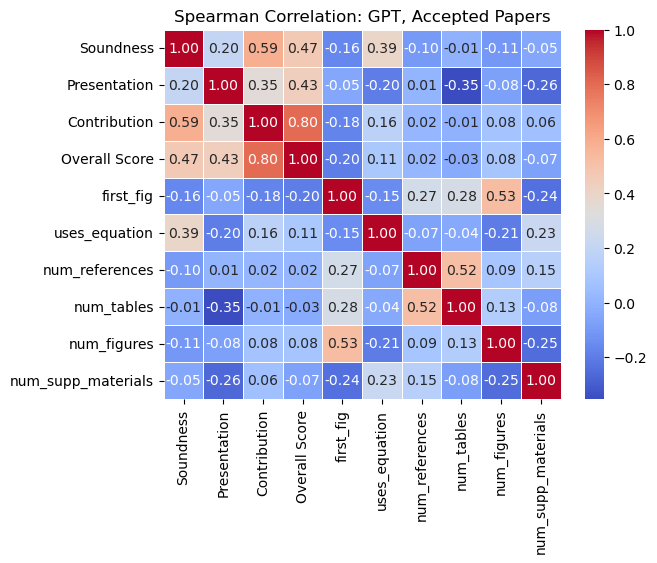

In [14]:
#Drop confidence score due to zero variation
df_gpt_filtered = df_gpt.drop(columns='Confidence Score')
corr_matrix = df_gpt_filtered.corr(method='spearman') 
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Spearman Correlation: GPT, Accepted Papers")

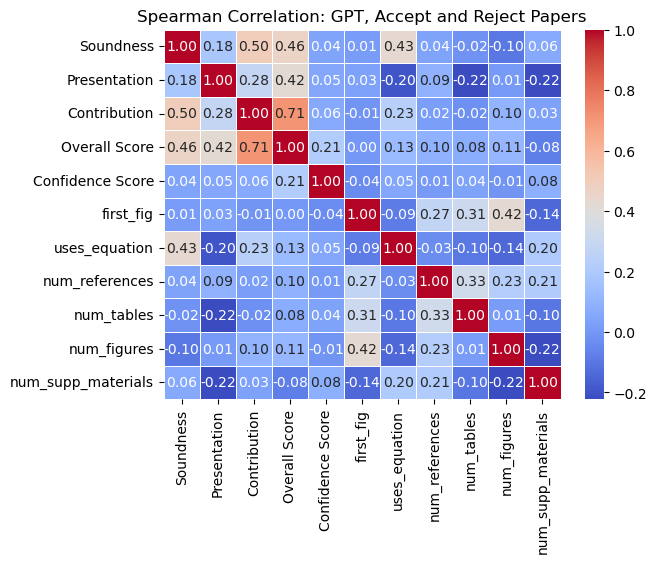

In [15]:
corr_matrix_gpt_all = df_gpt_all.corr(method='spearman') 
sns.heatmap(corr_matrix_gpt_all, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Spearman Correlation: GPT, Accept and Reject Papers")
plt.show()

Text(0.5, 1.0, 'Spearman Correlation: Gemini, Accept Papers')

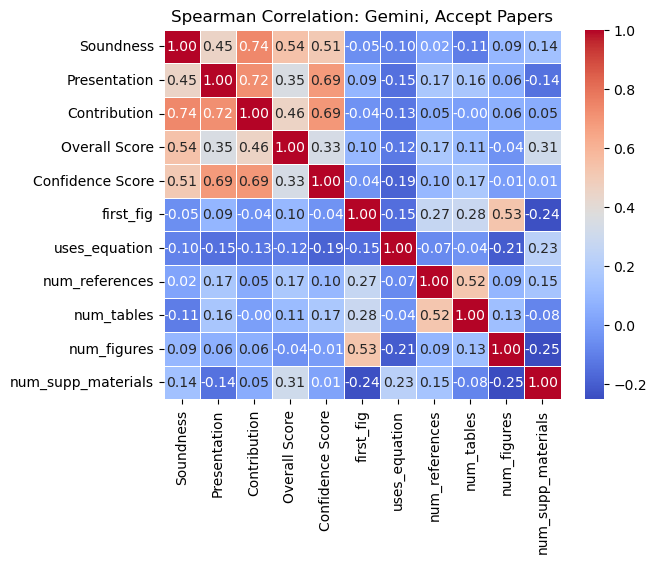

In [16]:
corr_matrix_gem = df_gem.corr(method='spearman') 
sns.heatmap(corr_matrix_gem, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Spearman Correlation: Gemini, Accept Papers")

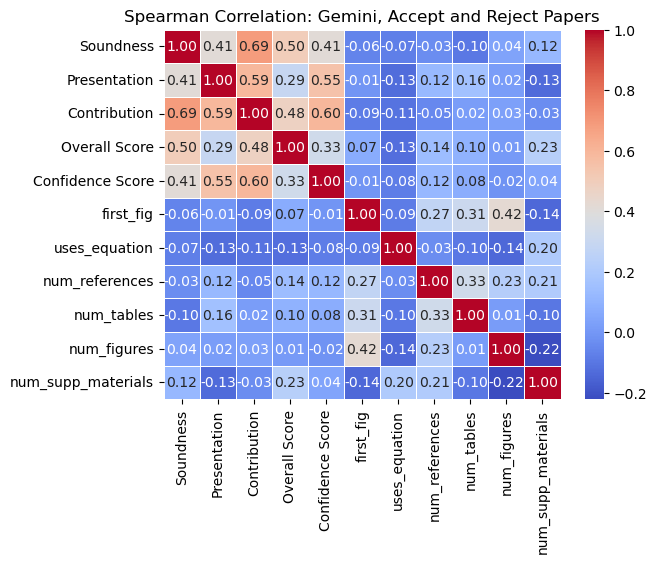

In [17]:
corr_matrix_gem_all = df_gem_all.corr(method='spearman') 
sns.heatmap(corr_matrix_gem_all, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Spearman Correlation: Gemini, Accept and Reject Papers")
plt.show()

## Distributions between LLM model ratings

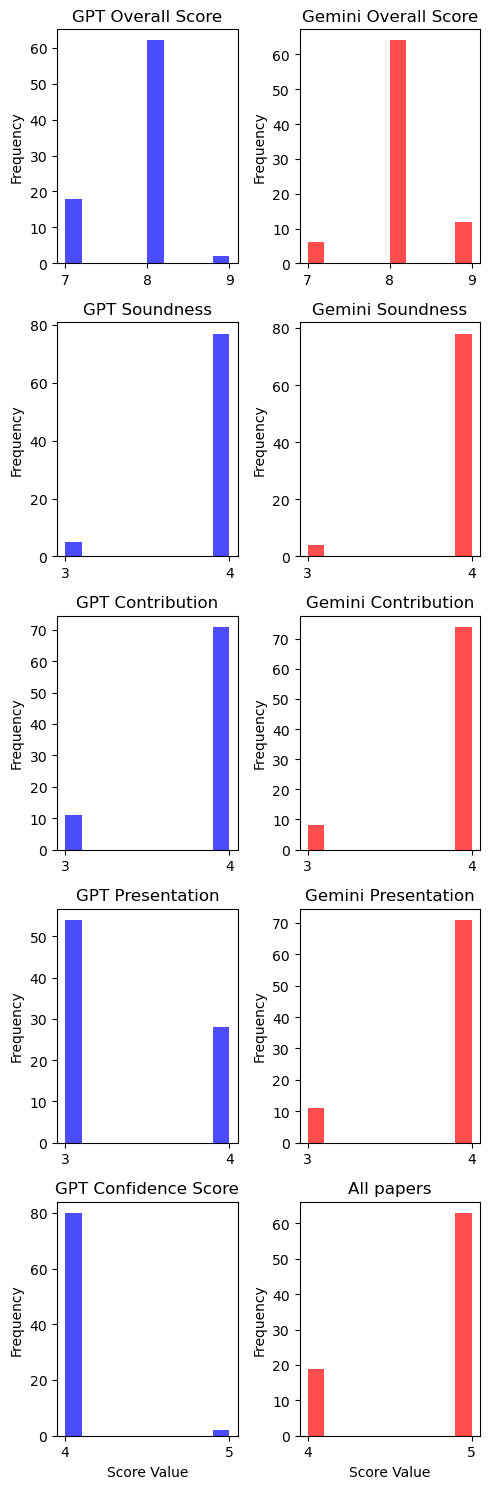

In [18]:
numerical_columns = ['Overall Score', 'Soundness', 'Contribution', 'Presentation', 'Confidence Score']
fig, axs = plt.subplots(len(numerical_columns), 2, figsize=(5, 15))

# Loop through each numerical column and plot histograms
for i, col in enumerate(numerical_columns):
    
    # GPT Scores Histogram
    axs[i, 0].hist(df_gpt_all[col].dropna(), bins=10, color='blue', alpha=0.7)
    axs[i, 0].set_ylabel('Frequency')
    axs[i, 0].set_title(f'GPT {col}')
    axs[i, 0].set_xticks(range(int(df_gpt_all[col].min()), int(df_gpt_all[col].max()) + 1))  

    # Gemini Scores Histogram
    axs[i, 1].hist(df_gem_all[col].dropna(), bins=10, color='red', alpha=0.7)
    axs[i, 1].set_ylabel('Frequency')
    axs[i, 1].set_title(f'Gemini {col}')
    axs[i, 1].set_xticks(range(int(df_gem_all[col].min()), int(df_gem_all[col].max()) + 1))  
    
    axs[-1, 0].set_xlabel('Score Value')
    axs[-1, 1].set_xlabel('Score Value')
    
plt.title('All papers')
plt.tight_layout()
plt.show()

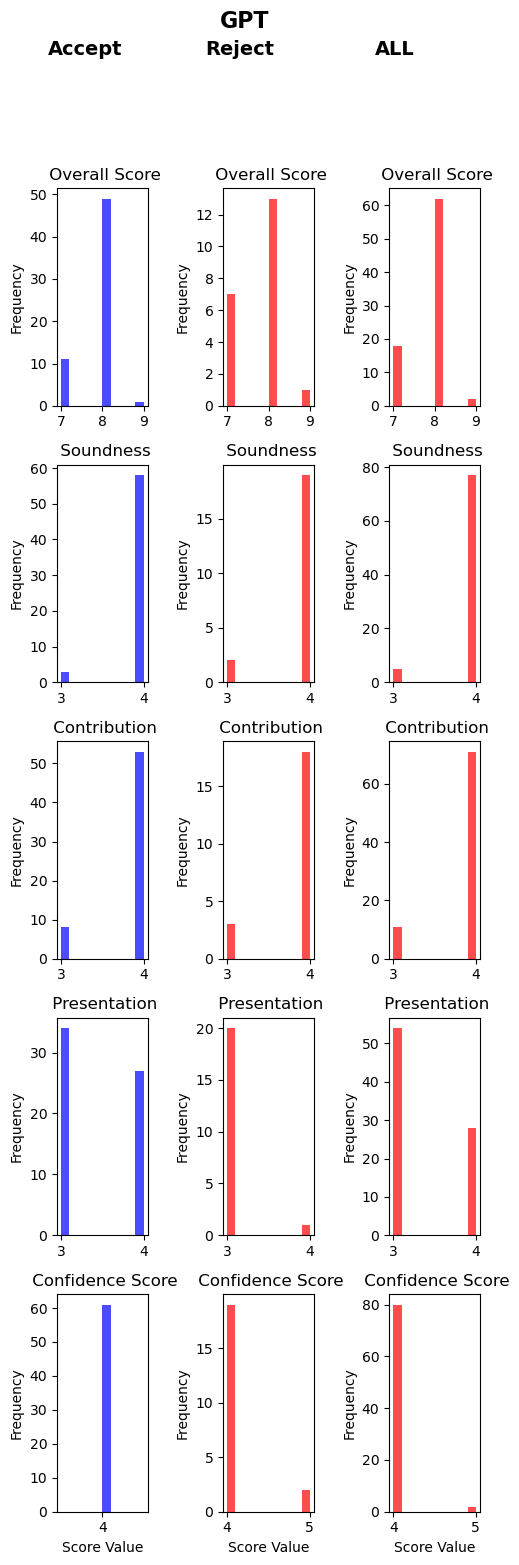

In [19]:
# Define numerical columns to plot
numerical_columns = ['Overall Score', 'Soundness', 'Contribution', 'Presentation', 'Confidence Score']

fig, axs = plt.subplots(len(numerical_columns), 3, figsize=(5, 15))
fig.suptitle("GPT", fontsize=16, fontweight='bold', y=1.04) 

# Loop through each numerical column and plot histograms
column_titles = ['Accept', 'Reject', 'ALL']
for i, title in enumerate(column_titles):
    fig.text(0.18 + i * 0.31, 1.01, title, fontsize=14, fontweight='bold', ha='center')
for i, col in enumerate(numerical_columns):
    
    # GPT Scores Accept Histogram
    axs[i, 0].hist(df_gpt[col].dropna(), bins=10, color='blue', alpha=0.7)
    axs[i, 0].set_ylabel('Frequency')
    axs[i, 0].set_title(f' {col}')
    axs[i, 0].set_xticks(range(int(df_gpt[col].min()), int(df_gpt[col].max()) + 1))  

    # Gemini Scores Reject Histogram
    axs[i, 1].hist(df_gpt_r[col].dropna(), bins=10, color='red', alpha=0.7)
    axs[i, 1].set_ylabel('Frequency')
    axs[i, 1].set_title(f' {col}')
    axs[i, 1].set_xticks(range(int(df_gpt_r[col].min()), int(df_gpt_r[col].max()) + 1))  
    
    # Gemini Scores ALL Histogram
    axs[i, 2].hist(df_gpt_all[col].dropna(), bins=10, color='red', alpha=0.7)
    axs[i, 2].set_ylabel('Frequency')
    axs[i, 2].set_title(f' {col}')
    axs[i, 2].set_xticks(range(int(df_gpt_all[col].min()), int(df_gpt_all[col].max()) + 1))  
    
    axs[-1, 0].set_xlabel('Score Value')
    axs[-1, 1].set_xlabel('Score Value')
    axs[-1, 2].set_xlabel('Score Value')
plt.tight_layout()
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

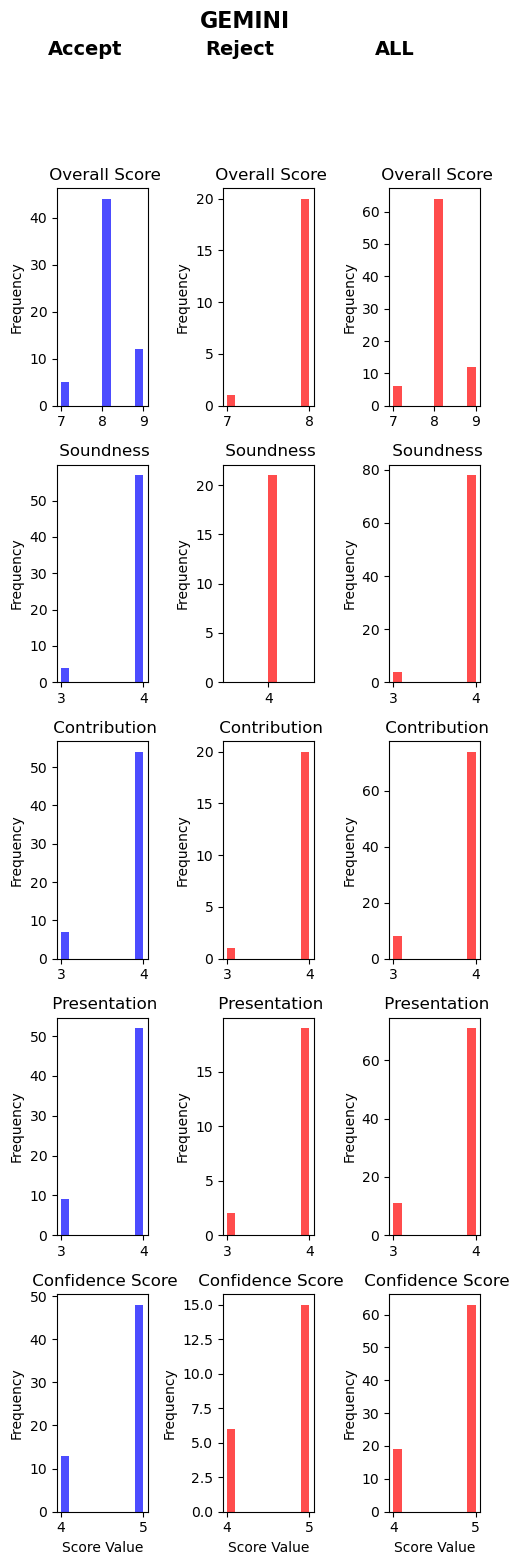

In [22]:
# Define numerical columns to plot
numerical_columns = ['Overall Score', 'Soundness', 'Contribution', 'Presentation', 'Confidence Score']

fig, axs = plt.subplots(len(numerical_columns), 3, figsize=(5, 15))
fig.suptitle("GEMINI", fontsize=16, fontweight='bold', y=1.04) 
# Loop through each numerical column and plot histograms
column_titles = ['Accept', 'Reject', 'ALL']
for i, title in enumerate(column_titles):
    fig.text(0.18 + i * 0.31, 1.01, title, fontsize=14, fontweight='bold', ha='center')
for i, col in enumerate(numerical_columns):
    # GPT Scores Accept Histogram
    axs[i, 0].hist(df_gem[col].dropna(), bins=10, color='blue', alpha=0.7)
    axs[i, 0].set_ylabel('Frequency')
    axs[i, 0].set_title(f' {col}')
    axs[i, 0].set_xticks(range(int(df_gem[col].min()), int(df_gem[col].max()) + 1))  

    # Gemini Scores Reject Histogram
    axs[i, 1].hist(df_gem_r[col].dropna(), bins=10, color='red', alpha=0.7)
    axs[i, 1].set_ylabel('Frequency')
    axs[i, 1].set_title(f' {col}')
    axs[i, 1].set_xticks(range(int(df_gem_r[col].min()), int(df_gem_r[col].max()) + 1))  
    
    # Gemini Scores ALL Histogram
    axs[i, 2].hist(df_gem_all[col].dropna(), bins=10, color='red', alpha=0.7)
    axs[i, 2].set_ylabel('Frequency')
    axs[i, 2].set_title(f' {col}')
    axs[i, 2].set_xticks(range(int(df_gem_all[col].min()), int(df_gem_all[col].max()) + 1))  
    

    axs[-1, 0].set_xlabel('Score Value')
    axs[-1, 1].set_xlabel('Score Value')
    axs[-1, 2].set_xlabel('Score Value')
plt.tight_layout()
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

/var/folders/94/mx6lg9691mncn51yb5t0j2yr0000gn/T/ipykernel_37688/3444657636.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df_gpt[col].dropna(), fill=True, color='blue', alpha=0.5, label="GPT Accept", ax=axs[i])


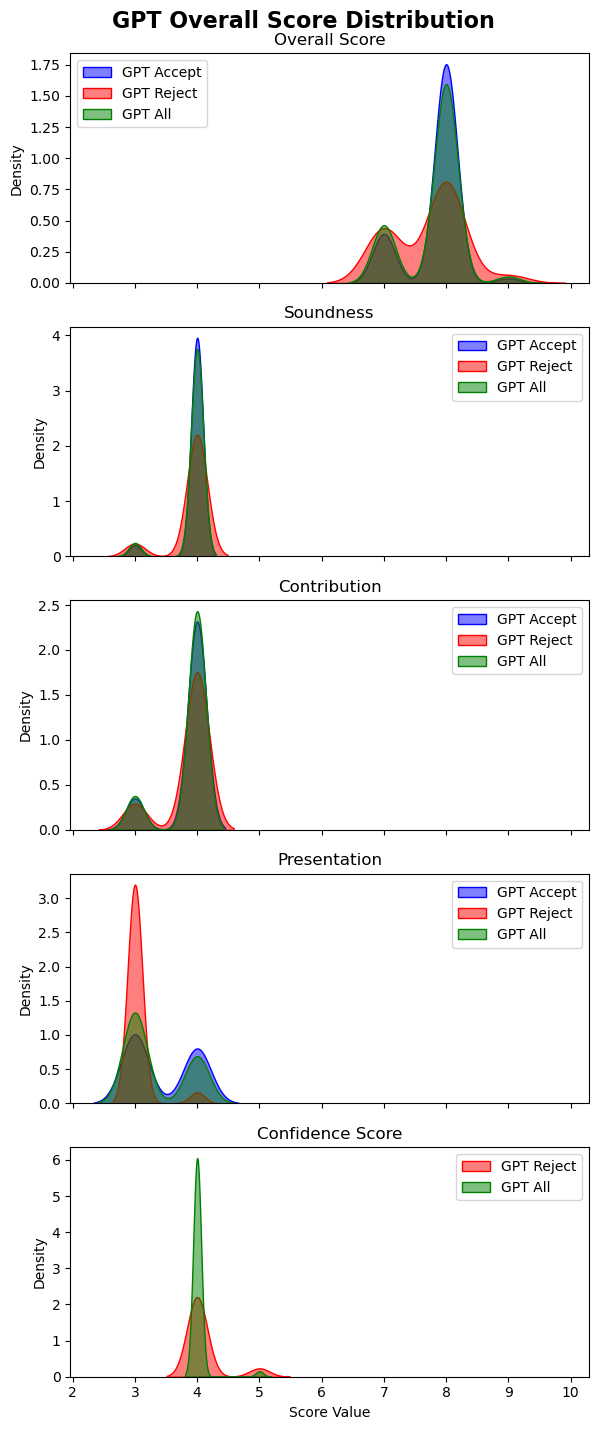

In [23]:
fig, axs = plt.subplots(len(numerical_columns), 1, figsize=(6, 15), sharex=True)
fig.suptitle("GPT Overall Score Distribution", fontsize=16, fontweight='bold', y=.95)  
# Loop through each numerical column and plot KDE distributions
for i, col in enumerate(numerical_columns):
    sns.kdeplot(df_gpt[col].dropna(), fill=True, color='blue', alpha=0.5, label="GPT Accept", ax=axs[i])
    sns.kdeplot(df_gpt_r[col].dropna(), fill=True, color='red', alpha=0.5, label="GPT Reject", ax=axs[i])
    sns.kdeplot(df_gpt_all[col].dropna(), fill=True, color='green', alpha=0.5, label="GPT All", ax=axs[i])

    axs[i].set_ylabel('Density')
    axs[i].set_title(f'{col}')
    axs[i].legend()
    
    axs[-1].set_xlabel('Score Value')
    
plt.tight_layout(rect=[0, 0, 1, 0.97]) 
plt.show()

/var/folders/94/mx6lg9691mncn51yb5t0j2yr0000gn/T/ipykernel_37688/2545582715.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df_gem_r[col].dropna(), fill=True, color='red', alpha=0.5, label="Gemini Reject", ax=axs[i])


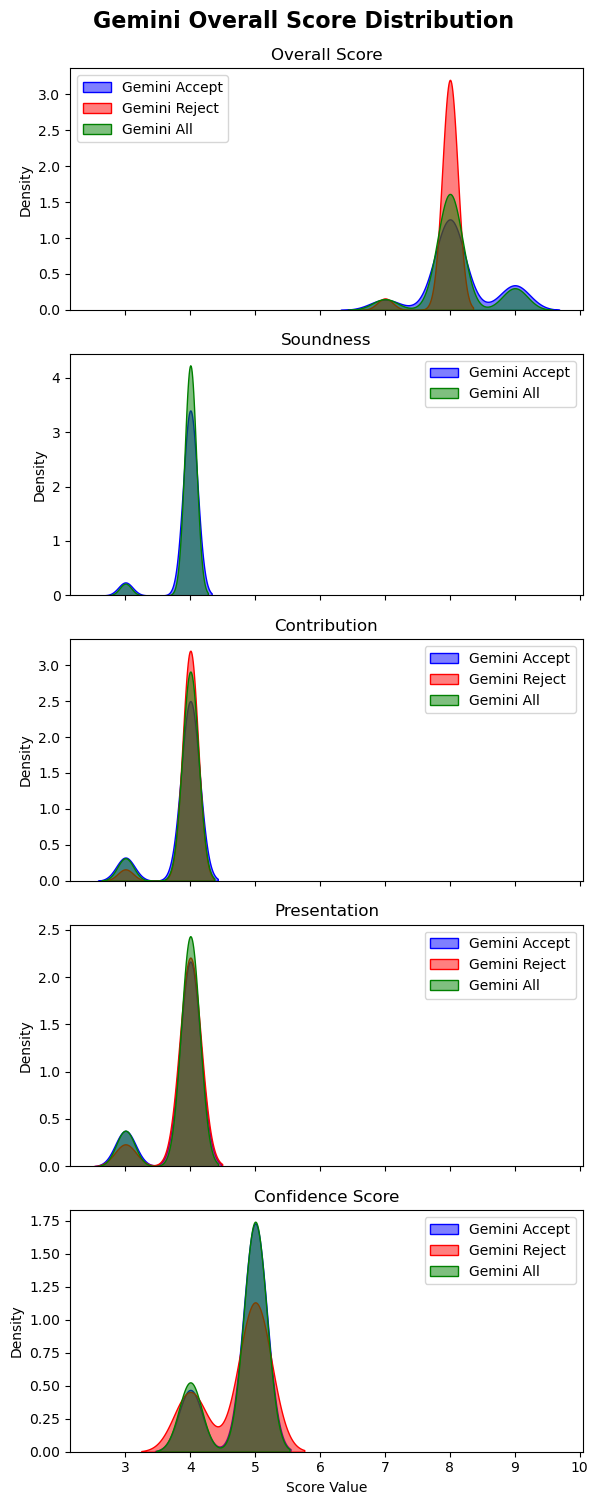

In [24]:

fig, axs = plt.subplots(len(numerical_columns), 1, figsize=(6, 15), sharex=True)
fig.suptitle("Gemini Overall Score Distribution", fontsize=16, fontweight='bold', y=1.00)  
# Loop through each numerical column and plot KDE distributions
for i, col in enumerate(numerical_columns):
    sns.kdeplot(df_gem[col].dropna(), fill=True, color='blue', alpha=0.5, label="Gemini Accept", ax=axs[i])
    sns.kdeplot(df_gem_r[col].dropna(), fill=True, color='red', alpha=0.5, label="Gemini Reject", ax=axs[i])
    sns.kdeplot(df_gem_all[col].dropna(), fill=True, color='green', alpha=0.5, label="Gemini All", ax=axs[i])

    axs[i].set_ylabel('Density')
    axs[i].set_title(f'{col}')
    axs[i].legend()
    
    axs[-1].set_xlabel('Score Value')
    
plt.tight_layout(rect=[0, 0, 1, 1.01])  
plt.show()

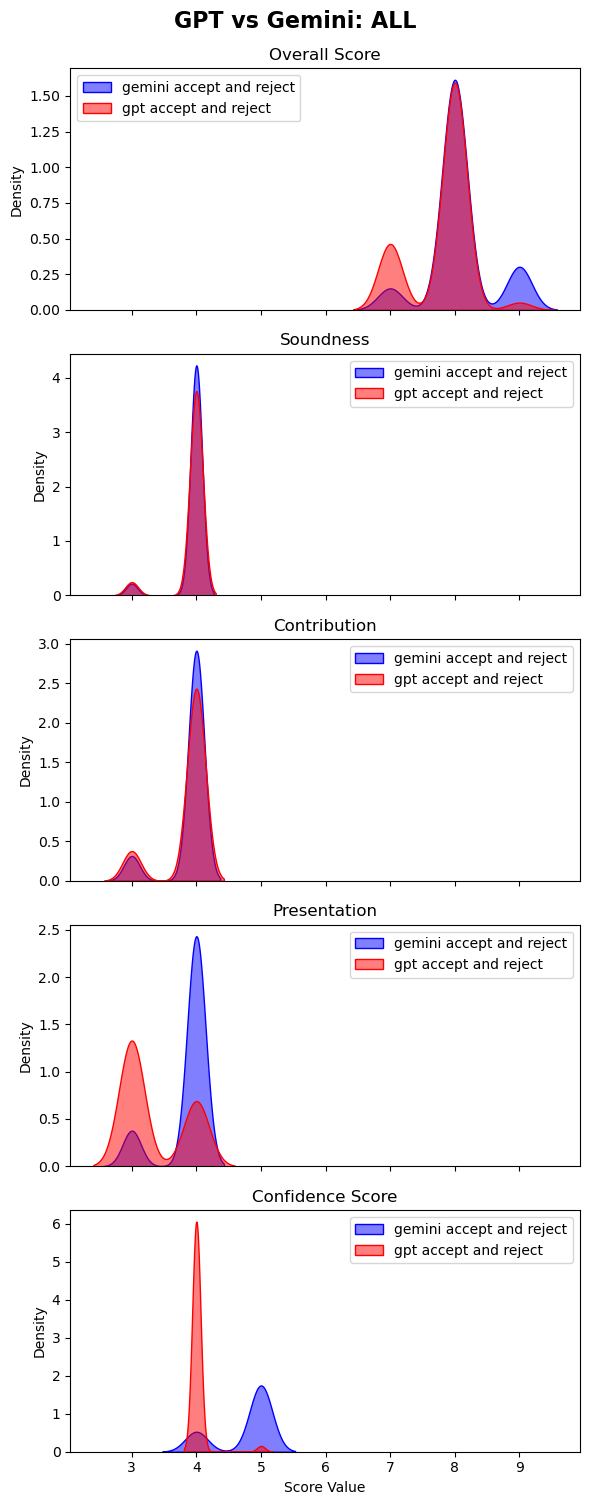

In [25]:
numerical_columns = ['Overall Score','Soundness','Contribution', 'Presentation','Confidence Score']

fig, axs = plt.subplots(len(numerical_columns), 1, figsize=(6, 15), sharex=True)

fig.suptitle("GPT vs Gemini: ALL", fontsize=16, fontweight='bold', y=1.00)  
# Loop through each numerical column and plot KDE distributions
for i, col in enumerate(numerical_columns):
    sns.kdeplot(df_gem_all[col].dropna(), fill=True, color='blue', alpha=0.5, label="gemini accept and reject", ax=axs[i])
    sns.kdeplot(df_gpt_all[col].dropna(), fill=True, color='red', alpha=0.5, label="gpt accept and reject", ax=axs[i])
    #sns.kdeplot(df_gem_all[col].dropna(), fill=True, color='green', alpha=0.5, label="GPT All", ax=axs[i])

    axs[i].set_ylabel('Density')
    axs[i].set_title(f'{col}')
    axs[i].legend()
    axs[-1].set_xlabel('Score Value')
plt.tight_layout(rect=[0, 0, 1, 1.01]) 
plt.show()

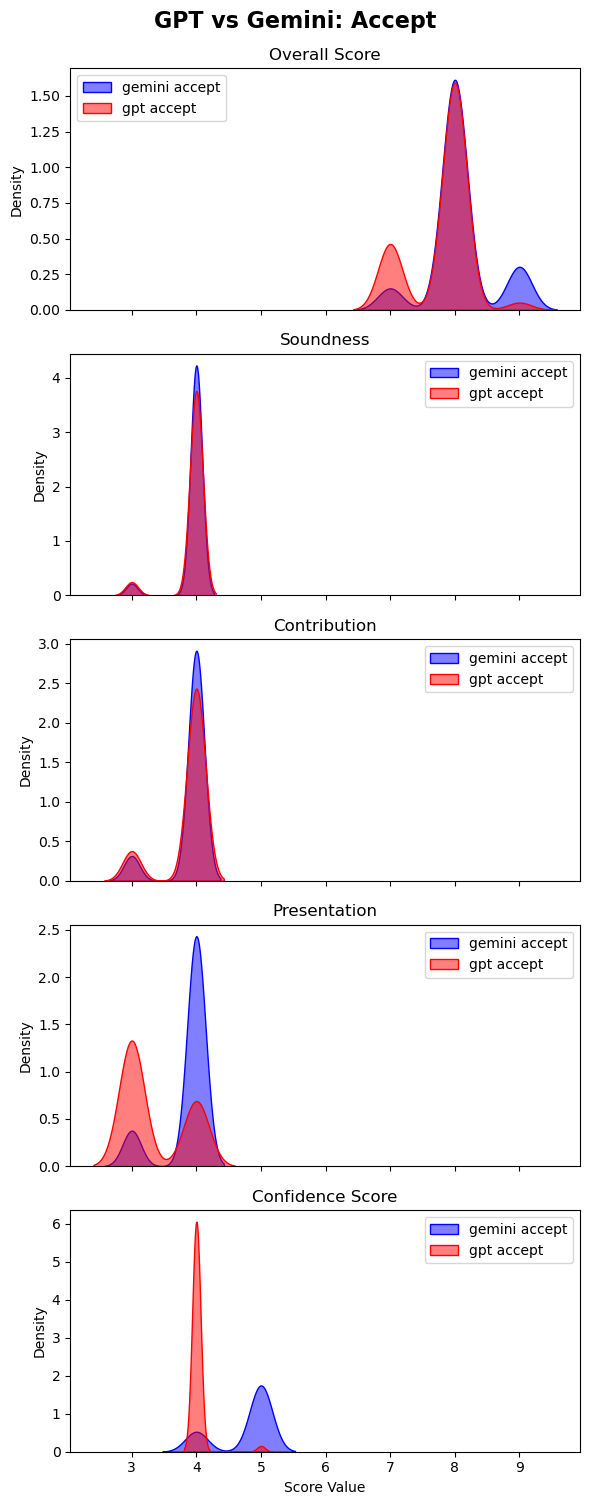

In [26]:

numerical_columns = ['Overall Score','Soundness','Contribution', 'Presentation','Confidence Score']

fig, axs = plt.subplots(len(numerical_columns), 1, figsize=(6, 15), sharex=True)

fig.suptitle("GPT vs Gemini: Accept", fontsize=16, fontweight='bold', y=1.00)  
# Loop through each numerical column and plot KDE distributions
for i, col in enumerate(numerical_columns):
    sns.kdeplot(df_gem_all[col].dropna(), fill=True, color='blue', alpha=0.5, label="gemini accept", ax=axs[i])
    sns.kdeplot(df_gpt_all[col].dropna(), fill=True, color='red', alpha=0.5, label="gpt accept", ax=axs[i])
    #sns.kdeplot(df_gem_all[col].dropna(), fill=True, color='green', alpha=0.5, label="GPT All", ax=axs[i])

    axs[i].set_ylabel('Density')
    axs[i].set_title(f'{col}')
    axs[i].legend()
    axs[-1].set_xlabel('Score Value')
plt.tight_layout(rect=[0, 0, 1, 1.01]) 
plt.show()

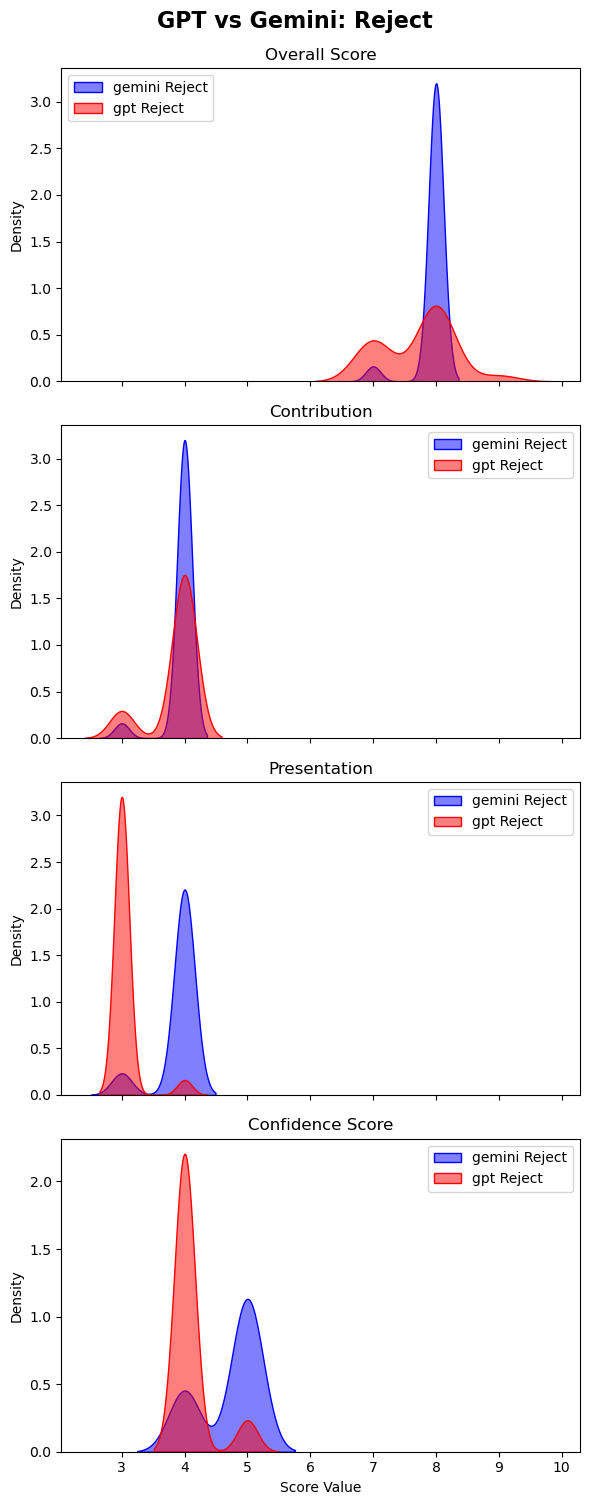

In [27]:

# Delete soundness no distribution available
numerical_columns = ['Overall Score','Contribution', 'Presentation','Confidence Score']

fig, axs = plt.subplots(len(numerical_columns), 1, figsize=(6, 15), sharex=True)

fig.suptitle("GPT vs Gemini: Reject", fontsize=16, fontweight='bold', y=1.00)  
# Loop through each numerical column and plot KDE distributions
for i, col in enumerate(numerical_columns):
    sns.kdeplot(df_gem_r[col].dropna(), fill=True, color='blue', alpha=0.5, label="gemini Reject", ax=axs[i])
    sns.kdeplot(df_gpt_r[col].dropna(), fill=True, color='red', alpha=0.5, label="gpt Reject", ax=axs[i])
    #sns.kdeplot(df_gem_all[col].dropna(), fill=True, color='green', alpha=0.5, label="GPT All", ax=axs[i])

    axs[i].set_ylabel('Density')
    axs[i].set_title(f'{col}')
    axs[i].legend()
    axs[-1].set_xlabel('Score Value')
plt.tight_layout(rect=[0, 0, 1, 1.01]) 
plt.show()

/var/folders/94/mx6lg9691mncn51yb5t0j2yr0000gn/T/ipykernel_37688/3382896539.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df_gpt[col].dropna(), fill=True, color='blue', alpha=0.5, label="GPT Accept", ax=axs[i])


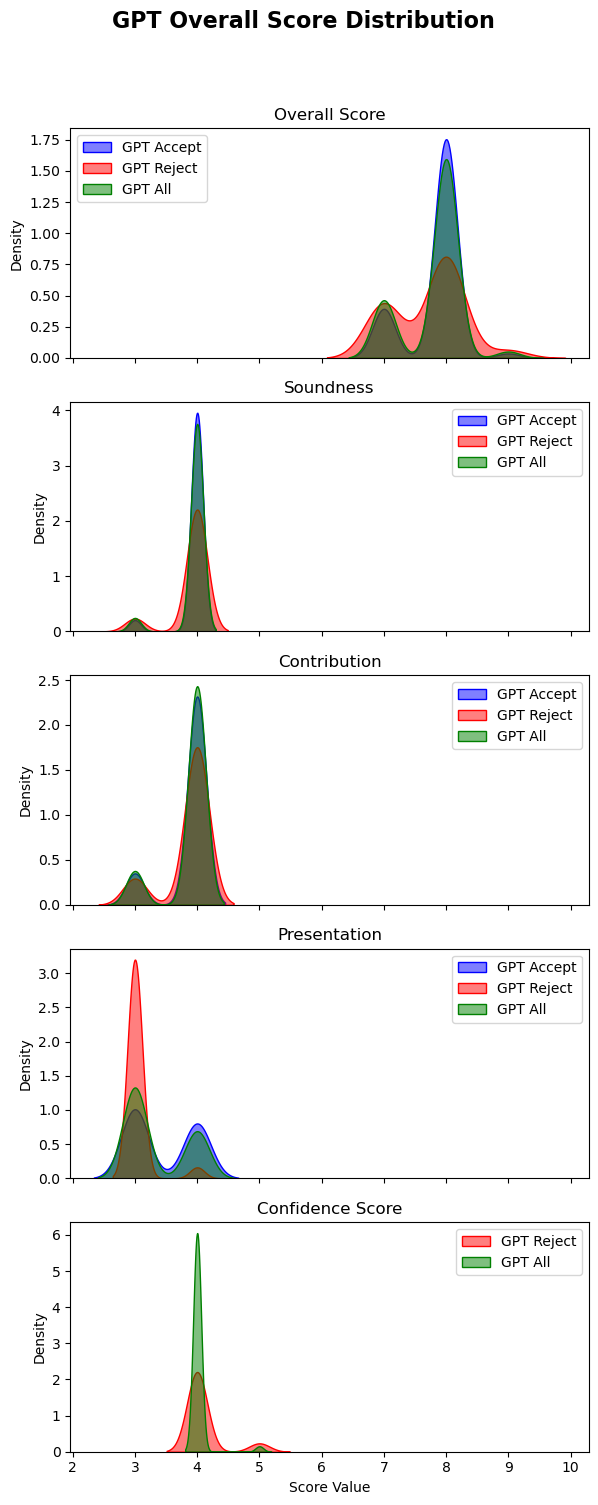

In [28]:
numerical_columns = ['Overall Score','Soundness','Contribution', 'Presentation','Confidence Score']
fig, axs = plt.subplots(len(numerical_columns), 1, figsize=(6, 15), sharex=True)
fig.suptitle("GPT Overall Score Distribution", fontsize=16, fontweight='bold', y=1.00)  
# Loop through each numerical column and plot KDE distributions
for i, col in enumerate(numerical_columns):
    sns.kdeplot(df_gpt[col].dropna(), fill=True, color='blue', alpha=0.5, label="GPT Accept", ax=axs[i])
    sns.kdeplot(df_gpt_r[col].dropna(), fill=True, color='red', alpha=0.5, label="GPT Reject", ax=axs[i])
    sns.kdeplot(df_gpt_all[col].dropna(), fill=True, color='green', alpha=0.5, label="GPT All", ax=axs[i])

    axs[i].set_ylabel('Density')
    axs[i].set_title(f'{col}')
    axs[i].legend()
    
    axs[-1].set_xlabel('Score Value')
    
plt.tight_layout(rect=[0, 0, 1, 0.97]) 
plt.show()

## MannWhiteney U test for GPT vs Gemini
Check if there is a significant difference between the various review score categories for accept, reject and all

In [29]:
#from tabulate import tabulate

# Define numerical columns for comparison
numerical_columns = ['Overall Score', 'Soundness', 'Contribution', 'Presentation', 'Confidence Score']
p_values = {}

# Perform Mann-Whitney U Test
for col in numerical_columns:
    stat, p_val = mannwhitneyu(df_gpt[col].dropna(), df_gem[col].dropna(), alternative='two-sided')
    p_values[col] = p_val

p_values_df = pd.DataFrame(list(p_values.items()), columns=['Metric', 'P-Value'])
p_values_df['Significance'] = p_values_df['P-Value'].apply(lambda x: "Significant" if x < 0.05 else "Not Significant")

# Print results in a tabular format
print('--------gpt vs gemini: Accept papers--------')
print("\nP-values from Mann-Whitney U Test:")
print(tabulate(p_values_df, headers='keys', tablefmt='grid'))

--------gpt vs gemini: Accept papers--------

P-values from Mann-Whitney U Test:
+----+------------------+-------------+-----------------+
|    | Metric           |     P-Value | Significance    |
+====+==================+=============+=================+
|  0 | Overall Score    | 0.00176109  | Significant     |
+----+------------------+-------------+-----------------+
|  1 | Soundness        | 0.702949    | Not Significant |
+----+------------------+-------------+-----------------+
|  2 | Contribution     | 0.787106    | Not Significant |
+----+------------------+-------------+-----------------+
|  3 | Presentation     | 2.41474e-06 | Significant     |
+----+------------------+-------------+-----------------+
|  4 | Confidence Score | 8.27629e-19 | Significant     |
+----+------------------+-------------+-----------------+


In [30]:
# Define numerical columns for comparison
numerical_columns = ['Overall Score', 'Soundness', 'Contribution', 'Presentation', 'Confidence Score']
p_values = {}

# Perform Mann-Whitney U Test
for col in numerical_columns:
    stat, p_val = mannwhitneyu(df_gpt_r[col].dropna(), df_gem_r[col].dropna(), alternative='two-sided')
    p_values[col] = p_val

p_values_df = pd.DataFrame(list(p_values.items()), columns=['Metric', 'P-Value'])
p_values_df['Significance'] = p_values_df['P-Value'].apply(lambda x: "Significant" if x < 0.05 else "Not Significant")

# Print results in a tabular format
print('--------gpt vs gemini: Reject papers--------')
print("\nP-values from Mann-Whitney U Test:")
print(tabulate(p_values_df, headers='keys', tablefmt='grid'))

--------gpt vs gemini: Reject papers--------

P-values from Mann-Whitney U Test:
+----+------------------+-------------+-----------------+
|    | Metric           |     P-Value | Significance    |
+====+==================+=============+=================+
|  0 | Overall Score    | 0.0639689   | Not Significant |
+----+------------------+-------------+-----------------+
|  1 | Soundness        | 0.162206    | Not Significant |
+----+------------------+-------------+-----------------+
|  2 | Contribution     | 0.310586    | Not Significant |
+----+------------------+-------------+-----------------+
|  3 | Presentation     | 4.25111e-08 | Significant     |
+----+------------------+-------------+-----------------+
|  4 | Confidence Score | 5.74682e-05 | Significant     |
+----+------------------+-------------+-----------------+


In [31]:
# Define numerical columns for comparison
numerical_columns = ['Overall Score', 'Soundness', 'Contribution', 'Presentation', 'Confidence Score']
p_values = {}

# Perform Mann-Whitney U Test
for col in numerical_columns:
    stat, p_val = mannwhitneyu(df_gpt_all[col].dropna(), df_gem_all[col].dropna(), alternative='two-sided')
    p_values[col] = p_val

p_values_df = pd.DataFrame(list(p_values.items()), columns=['Metric', 'P-Value'])
p_values_df['Significance'] = p_values_df['P-Value'].apply(lambda x: "Significant" if x < 0.05 else "Not Significant")

# Print results in a tabular format
print('--------gpt vs gemini: Accept and Reject papers--------')
print("\nP-values from Mann-Whitney U Test:")
print(tabulate(p_values_df, headers='keys', tablefmt='grid'))

--------gpt vs gemini: Accept and Reject papers--------

P-values from Mann-Whitney U Test:
+----+------------------+-------------+-----------------+
|    | Metric           |     P-Value | Significance    |
+====+==================+=============+=================+
|  0 | Overall Score    | 0.00035832  | Significant     |
+----+------------------+-------------+-----------------+
|  1 | Soundness        | 0.73562     | Not Significant |
+----+------------------+-------------+-----------------+
|  2 | Contribution     | 0.467379    | Not Significant |
+----+------------------+-------------+-----------------+
|  3 | Presentation     | 7.82522e-12 | Significant     |
+----+------------------+-------------+-----------------+
|  4 | Confidence Score | 2.82892e-22 | Significant     |
+----+------------------+-------------+-----------------+


In [32]:
# Define numerical columns for comparison
numerical_columns = ['Overall Score', 'Soundness', 'Contribution', 'Presentation', 'Confidence Score']
p_values = {}

# Perform Mann-Whitney U Test
for col in numerical_columns:
    stat, p_val = mannwhitneyu(df_gpt[col].dropna(), df_gpt_r[col].dropna(), alternative='two-sided')
    p_values[col] = p_val

p_values_df = pd.DataFrame(list(p_values.items()), columns=['Metric', 'P-Value'])
p_values_df['Significance'] = p_values_df['P-Value'].apply(lambda x: "Significant" if x < 0.05 else "Not Significant")

# Print results in a tabular format
print('--------gpt accept vs gpt reject-------')
print("\nP-values from Mann-Whitney U Test:")
print(tabulate(p_values_df, headers='keys', tablefmt='grid'))

--------gpt accept vs gpt reject-------

P-values from Mann-Whitney U Test:
+----+------------------+------------+-----------------+
|    | Metric           |    P-Value | Significance    |
+====+==================+============+=================+
|  0 | Overall Score    | 0.25788    | Not Significant |
+----+------------------+------------+-----------------+
|  1 | Soundness        | 0.457299   | Not Significant |
+----+------------------+------------+-----------------+
|  2 | Contribution     | 0.899755   | Not Significant |
+----+------------------+------------+-----------------+
|  3 | Presentation     | 0.00109173 | Significant     |
+----+------------------+------------+-----------------+
|  4 | Confidence Score | 0.0161533  | Significant     |
+----+------------------+------------+-----------------+


In [33]:
# Define numerical columns for comparison
numerical_columns = ['Overall Score', 'Soundness', 'Contribution', 'Presentation', 'Confidence Score']
p_values = {}

# Perform Mann-Whitney U Test
for col in numerical_columns:
    stat, p_val = mannwhitneyu(df_gem[col].dropna(), df_gem_r[col].dropna(), alternative='two-sided')
    p_values[col] = p_val

p_values_df = pd.DataFrame(list(p_values.items()), columns=['Metric', 'P-Value'])
p_values_df['Significance'] = p_values_df['P-Value'].apply(lambda x: "Significant" if x < 0.05 else "Not Significant")

# Print results in a tabular format
print('--------gemini accept vs gemini reject-------')
print("\nP-values from Mann-Whitney U Test:")
print(tabulate(p_values_df, headers='keys', tablefmt='grid'))

--------gemini accept vs gemini reject-------

P-values from Mann-Whitney U Test:
+----+------------------+-----------+-----------------+
|    | Metric           |   P-Value | Significance    |
+====+==================+===========+=================+
|  0 | Overall Score    |  0.15132  | Not Significant |
+----+------------------+-----------+-----------------+
|  1 | Soundness        |  0.237366 | Not Significant |
+----+------------------+-----------+-----------------+
|  2 | Contribution     |  0.37969  | Not Significant |
+----+------------------+-----------+-----------------+
|  3 | Presentation     |  0.552604 | Not Significant |
+----+------------------+-----------+-----------------+
|  4 | Confidence Score |  0.503709 | Not Significant |
+----+------------------+-----------+-----------------+


## Primary Area vs Overall Score (LLM)

In [34]:
# Primary Area vs Overall Score
df_primary_area = df_gpt[['Overall Score', 'primary_area']]
df_primary_area_r = df_gpt_r[['Overall Score', 'primary_area']]
df_primary_area_all = df_gpt_all[['Overall Score', 'primary_area']]

# Obtain unique values of primary area
unique_values = df_gpt["primary_area"].unique()
unique_values_r = df_gpt_r["primary_area"].unique()
unique_values_all = df_gpt_all["primary_area"].unique()

In [35]:
# Calculate mean and median Overall Score for each Primary Area
dfs=[df_gpt, df_gem]
for d in dfs:
    score_stats = d.groupby("primary_area")["Overall Score"].agg(["mean", "median"]).reset_index()
    area_counts = d["primary_area"].value_counts().reset_index()
    area_counts.columns = ["primary_area", "Frequency"]

    primary_area_summary_df = pd.merge(score_stats, area_counts, on="primary_area")

    print(primary_area_summary_df)

                                         primary_area      mean  median  \
0                                             Bandits  8.000000     8.0   
1                                    Causal inference  8.000000     8.0   
2                         Deep learning architectures  8.000000     8.0   
3                              Diffusion based models  7.750000     8.0   
4                                   Generative models  8.000000     8.0   
5                               Graph neural networks  8.000000     8.0   
6                                Human-AI interaction  7.500000     7.5   
7   Infrastructure (libraries, improved implementa...  7.000000     7.0   
8                 Interpretability and explainability  7.000000     7.0   
9                                     Learning theory  8.000000     8.0   
10                    Machine learning for healthcare  7.000000     7.0   
11     Machine learning for other sciences and fields  8.000000     8.0   
12  Machine learning for 

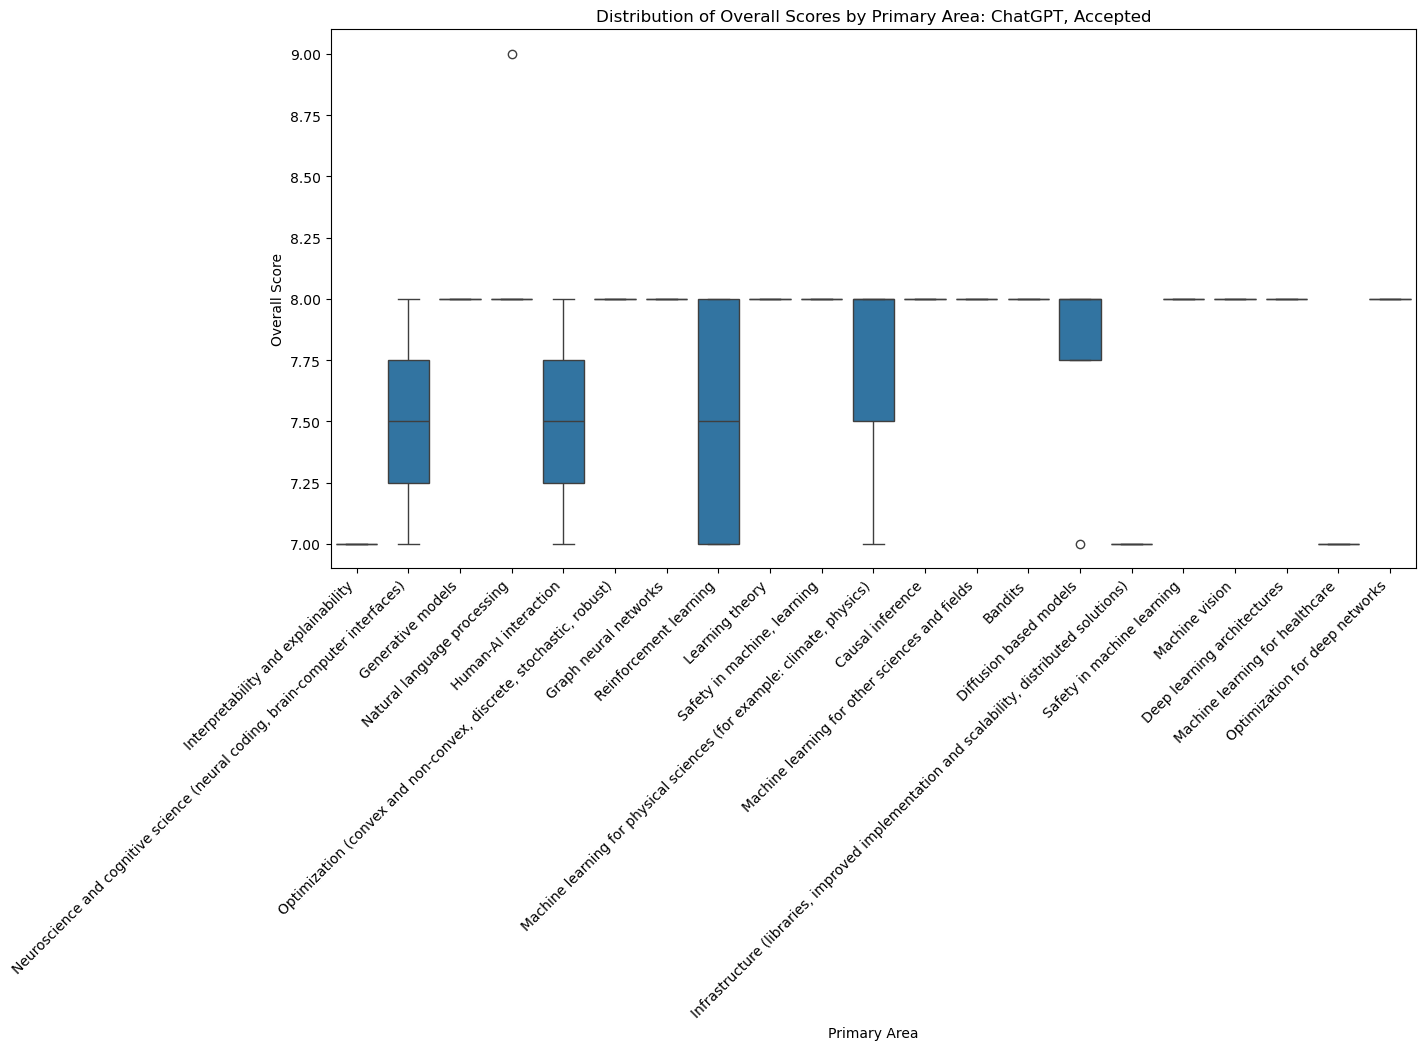

In [36]:
plt.figure(figsize=(14, 7))
# Create a boxplot to compare scores across Primary Areas
sns.boxplot(x=df_gpt["primary_area"], y=df_gpt["Overall Score"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Primary Area")
plt.ylabel("Overall Score")
plt.title("Distribution of Overall Scores by Primary Area: ChatGPT, Accepted")
plt.show()

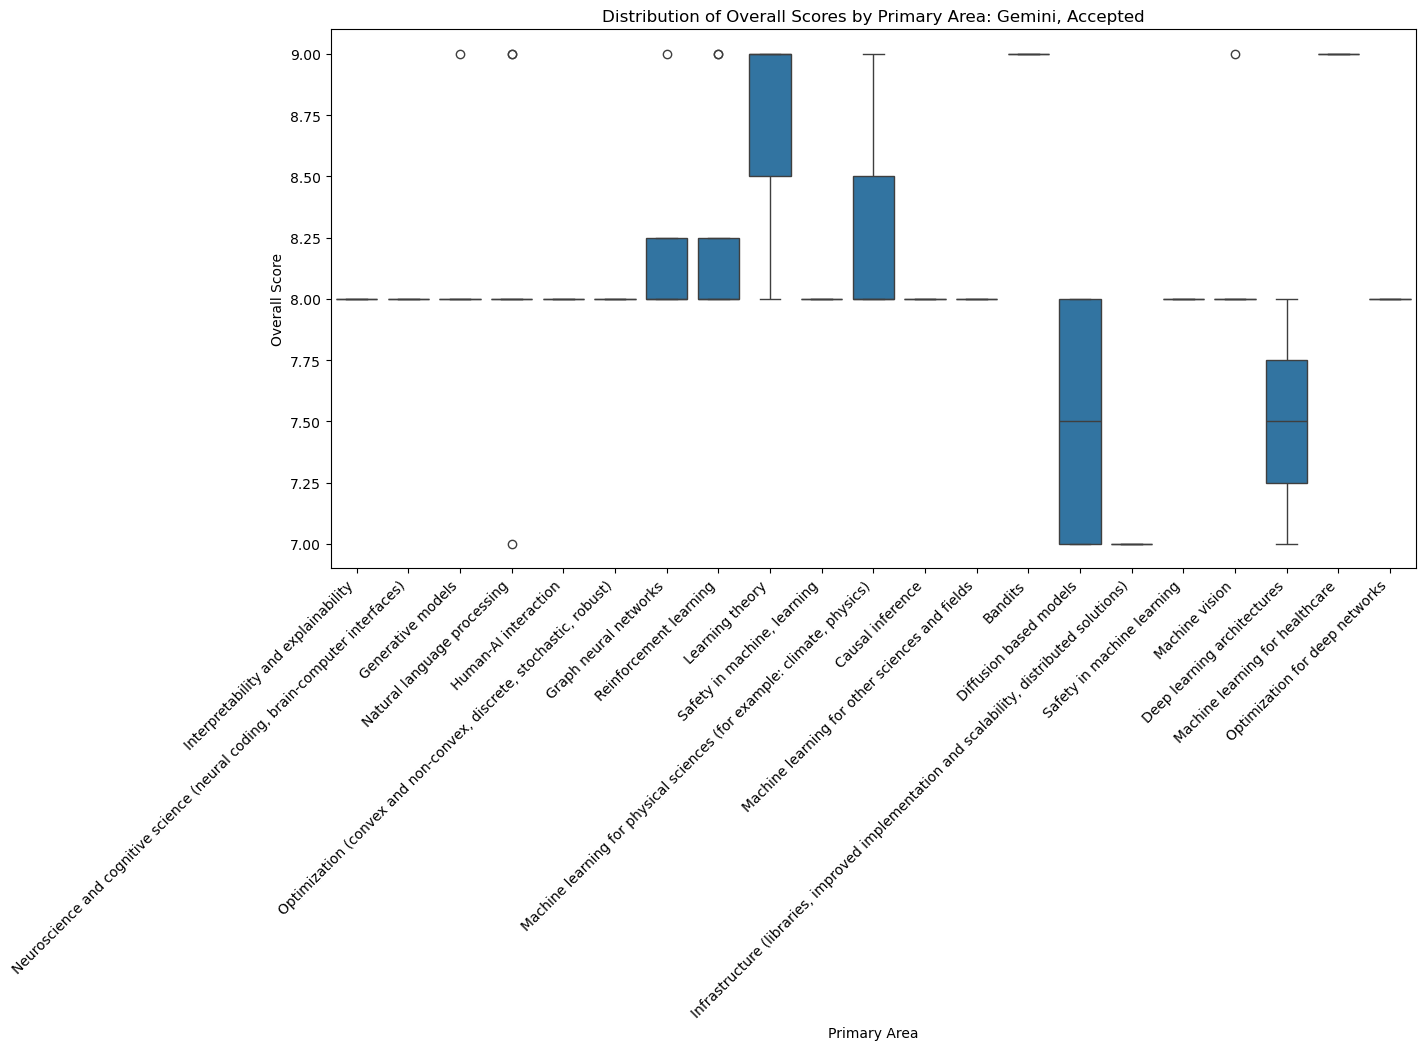

In [37]:
plt.figure(figsize=(14, 7))
# Create a boxplot to compare scores across Primary Areas
sns.boxplot(x=df_gem["primary_area"], y=df_gem["Overall Score"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Primary Area")
plt.ylabel("Overall Score")
plt.title("Distribution of Overall Scores by Primary Area: Gemini, Accepted")
plt.show()

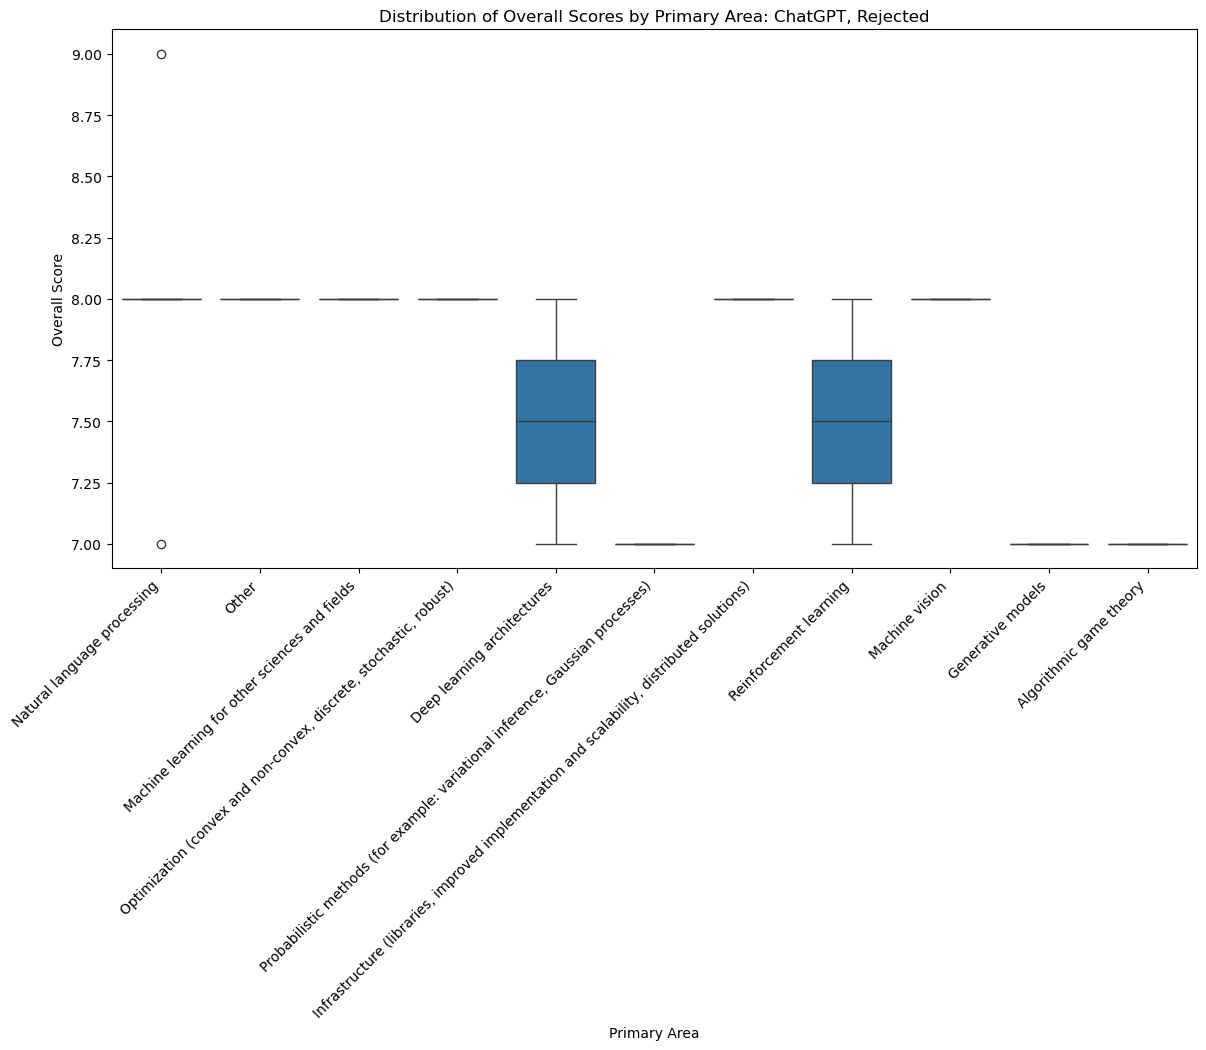

In [38]:

plt.figure(figsize=(14, 7))
# Create a boxplot to compare scores across Primary Areas
sns.boxplot(x=df_gpt_r["primary_area"], y=df_gpt_r["Overall Score"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Primary Area")
plt.ylabel("Overall Score")
plt.title("Distribution of Overall Scores by Primary Area: ChatGPT, Rejected")
plt.show()

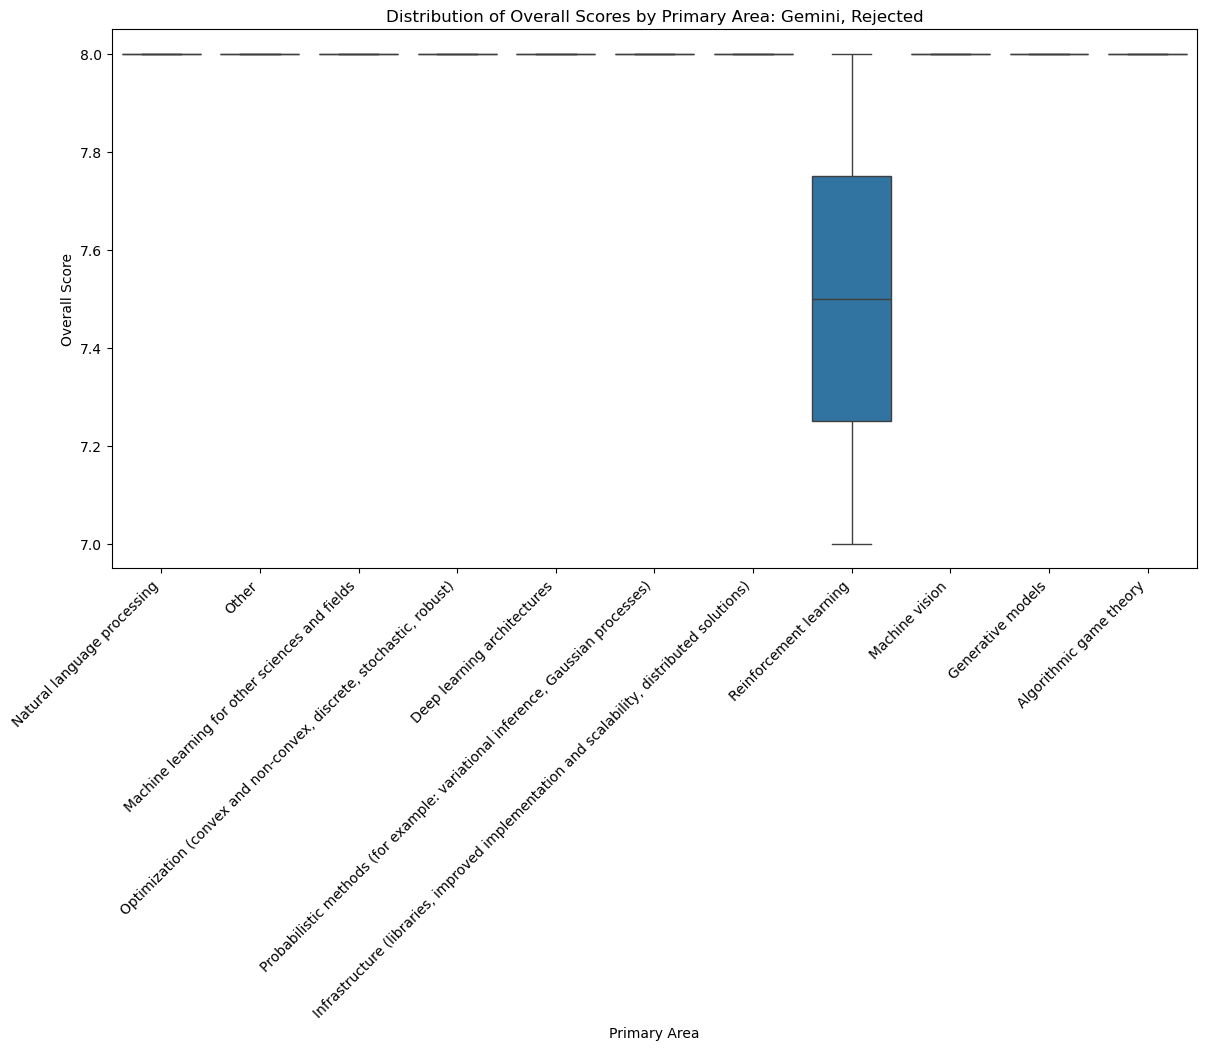

In [39]:
plt.figure(figsize=(14, 7))
# Create a boxplot to compare scores across Primary Areas
sns.boxplot(x=df_gem_r["primary_area"], y=df_gem_r["Overall Score"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Primary Area")
plt.ylabel("Overall Score")
plt.title("Distribution of Overall Scores by Primary Area: Gemini, Rejected")
plt.show()

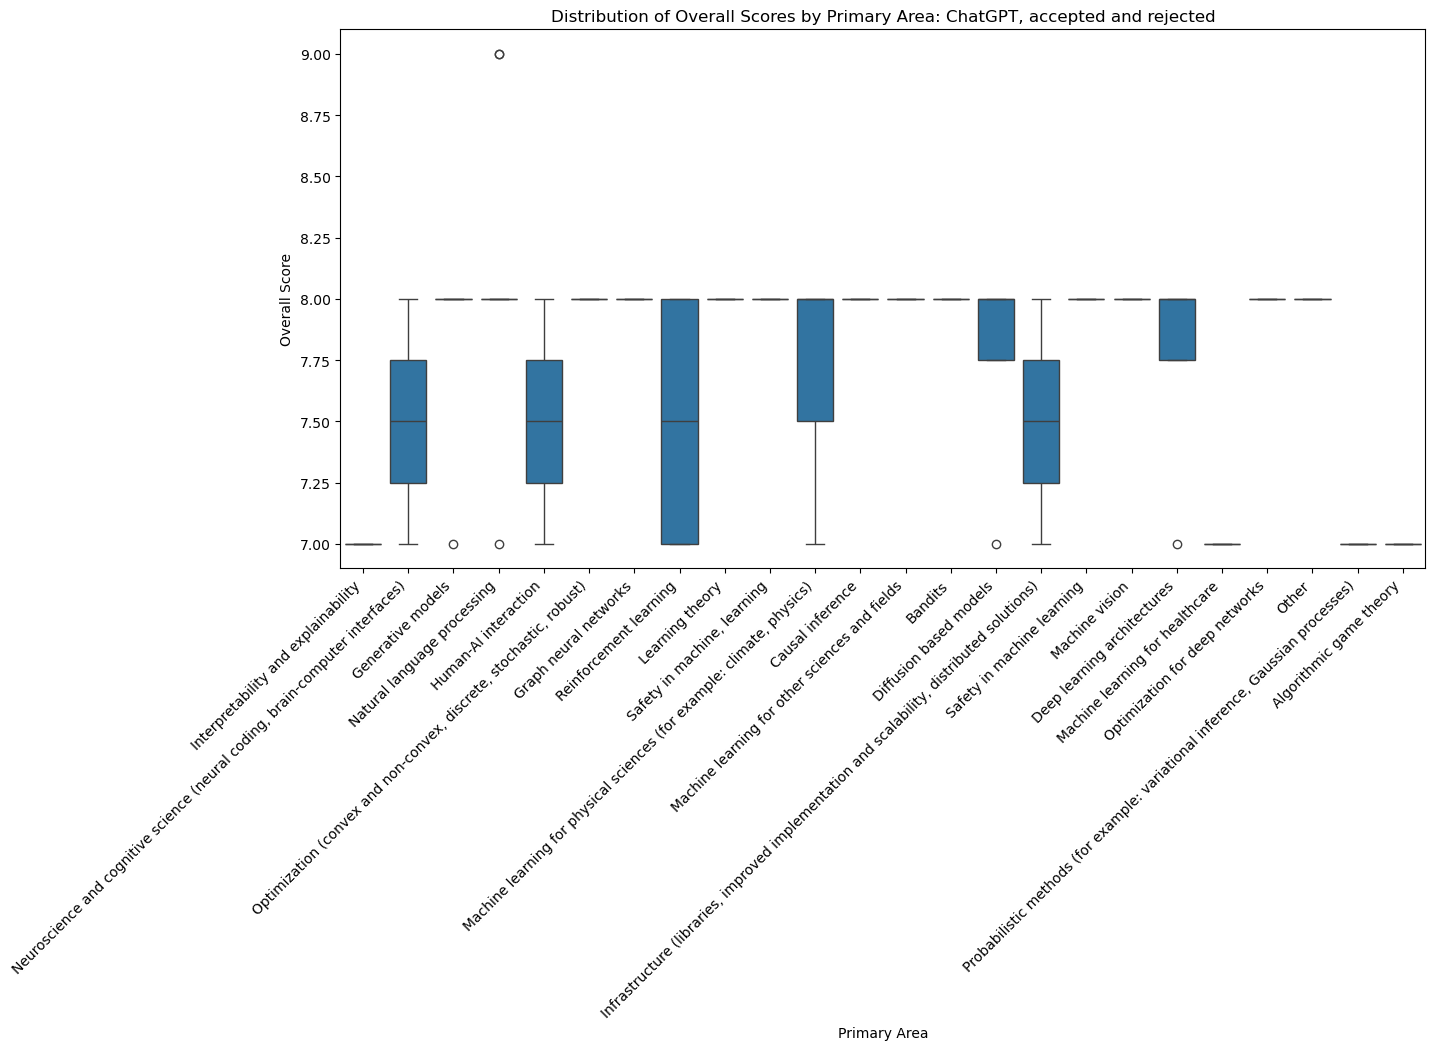

In [40]:

plt.figure(figsize=(14, 7))
# Create a boxplot to compare scores across Primary Areas
sns.boxplot(x=df_gpt_all["primary_area"], y=df_gpt_all["Overall Score"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Primary Area")
plt.ylabel("Overall Score")
plt.title("Distribution of Overall Scores by Primary Area: ChatGPT, accepted and rejected")
plt.show()

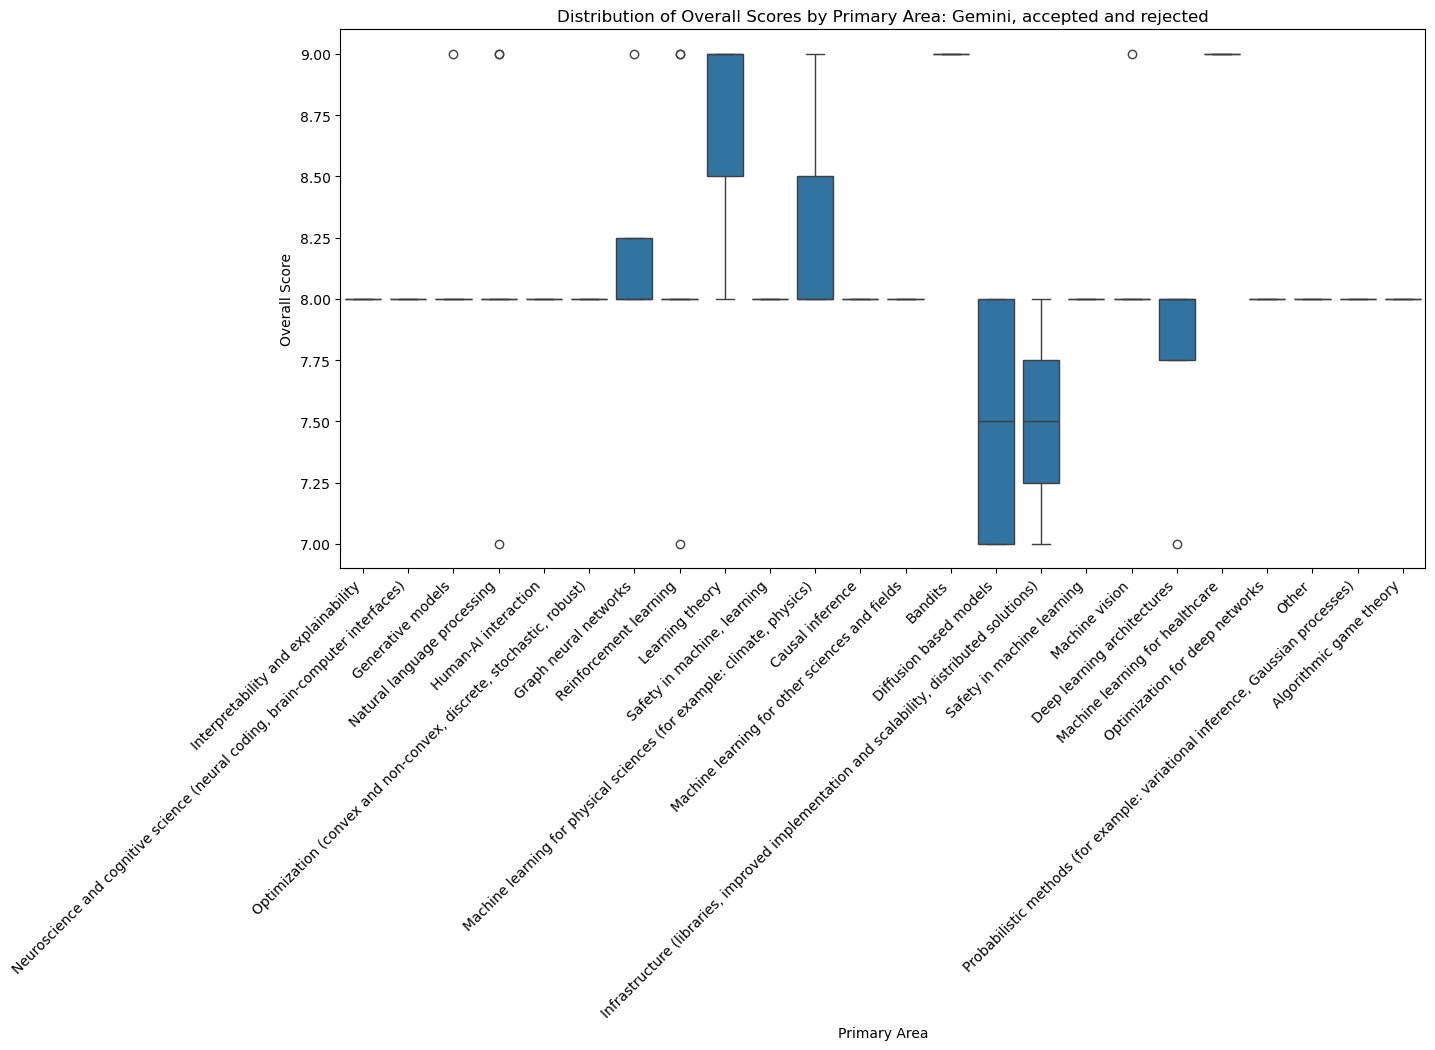

In [41]:
plt.figure(figsize=(14, 7))
# Create a boxplot to compare scores across Primary Areas
sns.boxplot(x=df_gem_all["primary_area"], y=df_gem_all["Overall Score"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Primary Area")
plt.ylabel("Overall Score")
plt.title("Distribution of Overall Scores by Primary Area: Gemini, accepted and rejected")
plt.show()

In [42]:
#from scipy.stats import shapiro
# Perform normality test on Overall Scores for all model reviewers and categories
_, p1 = shapiro(df_gpt["Overall Score"].dropna())
_, p2 = shapiro(df_gpt_r["Overall Score"].dropna())
_, p3 = shapiro(df_gpt_all["Overall Score"].dropna())
_, p4 = shapiro(df_gem["Overall Score"].dropna())
_, p5 = shapiro(df_gem_r["Overall Score"].dropna())
_, p6 = shapiro(df_gem_all["Overall Score"].dropna())
p = [p1,p2,p3,p4,p5,p6]
for i in p:
    print(f"Shapiro-Wilk Test p-value: {i:.5f}")
    if i > 0.05:
        print("✅ Scores appear to be normally distributed (fail to reject H0).")
    else:
        print("❌ Scores are NOT normally distributed (reject H0).")

Shapiro-Wilk Test p-value: 0.00000
❌ Scores are NOT normally distributed (reject H0).
Shapiro-Wilk Test p-value: 0.00006
❌ Scores are NOT normally distributed (reject H0).
Shapiro-Wilk Test p-value: 0.00000
❌ Scores are NOT normally distributed (reject H0).
Shapiro-Wilk Test p-value: 0.00000
❌ Scores are NOT normally distributed (reject H0).
Shapiro-Wilk Test p-value: 0.00000
❌ Scores are NOT normally distributed (reject H0).
Shapiro-Wilk Test p-value: 0.00000
❌ Scores are NOT normally distributed (reject H0).


## Human Reviewer Data

In [43]:
# Generate a human review from directory
def human_review(directory):
    ''' Input: directory, Output: Dataframe containing human reviewer data'''
    categories = ["soundness", "presentation", "contribution", "rating", "confidence"]

    all_data = []
    # Loop through each folder in the base directory
    for folder_name in os.listdir(directory):
        folder_path = os.path.join(directory, folder_name)

        # Ensure it's a directory
        if os.path.isdir(folder_path):
            json_file_path = os.path.join(folder_path, "official_review_details.json")  

            # Check if the JSON file exists in the folder
            if os.path.exists(json_file_path):
                with open(json_file_path, "r", encoding="utf-8") as f:
                    try:
                        data = json.load(f)  

                        # Ensure JSON data is a list
                        if isinstance(data, list):
                            extracted_data = {key: [] for key in categories}  # Create empty lists for each category

                            for entry in data: 
                                for key in categories:
                                    # Extract value from the nested dictionary
                                    extracted_data[key].append(entry.get(key, {}).get("value", None))  

                            # Convert lists to numeric and compute means
                            avg_scores = {key: pd.to_numeric(extracted_data[key], errors='coerce').mean() for key in categories}
                            avg_scores["folder"] = folder_name  

                            # Debugging: Print extracted and processed data
                            #print(f"✅ Extracted from {folder_name}: {avg_scores}")

                            # Append results
                            all_data.append(avg_scores)

                        else:
                            print(f"⚠️ Unexpected JSON format in {json_file_path} (Expected a list).")

                    except json.JSONDecodeError:
                        print(f"⚠️ Error decoding JSON in: {json_file_path}")

    return pd.DataFrame(all_data)


In [49]:
# Directories correspond do different batches of data
base_directory1 = '../data/data1' #0-25
base_directory2 = '../data/data2'
base_directory3 = '../data/data3'
base_directory1_r = '../data/data_r1'
base_directory2_r = '../data/data_r2'
df_official1 = human_review(base_directory1)
df_official2 = human_review(base_directory2)
df_official2.index = range(25, 25 + df_official2.shape[0])
df_official3 = human_review(base_directory2)
df_official3.index = range(50, 50 + df_official3.shape[0]) # Set index 
df_official_r1 = human_review(base_directory1_r)
df_official_r2 = human_review(base_directory2_r)

In [50]:
df_official =  pd.concat([df_official1, df_official2, df_official3]) # Concatenate the accepted 
df_official = df_official.rename_axis("Paper_index")
df_official.columns = df_official.columns.str.capitalize()
df_official = df_official.rename(columns={"Rating": "Overall Score", 'Confidence': 'Confidence Score'})
df_official["primary_area"] = df_gpt["primary_area"]


df_official_r =  pd.concat([df_official_r1, df_official_r2]) # Concatenate the rejected 
df_official_r = df_official_r.rename_axis("Paper_index")
df_official_r.columns = df_official_r.columns.str.capitalize()
df_official_r = df_official_r.rename(columns={"Rating": "Overall Score", 'Confidence': 'Confidence Score'})
df_official_r["primary_area"] = df_gpt_r["primary_area"]



In [51]:
df_official.head()

,Soundness,Presentation,Contribution,Overall Score,Confidence Score,Folder,primary_area
Paper_index,,,,,,,
0,3.25,3.50,3.25,7.25,3.75,aVh9KRZdRk,Interpretability and explainability
1,3.50,3.50,3.50,7.00,4.75,TFZlFRl9Ks,Neuroscience and cognitive science (neural cod...
2,2.75,3.50,2.75,6.75,3.50,4NJBV6Wp0h,Generative models
3,3.00,3.25,3.00,7.25,4.00,9O2sVnEHor,Natural language processing
4,3.00,3.25,3.25,6.75,3.25,V0oJaLqY4E,Human-AI interaction


## Human vs GPT vs Gemini (Accepted Papers) Distribution

/var/folders/94/mx6lg9691mncn51yb5t0j2yr0000gn/T/ipykernel_37688/4003858130.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df_gpt[col].dropna(), fill=True, color='red', alpha=0.5, label="GPT Accept", ax=axs[i])


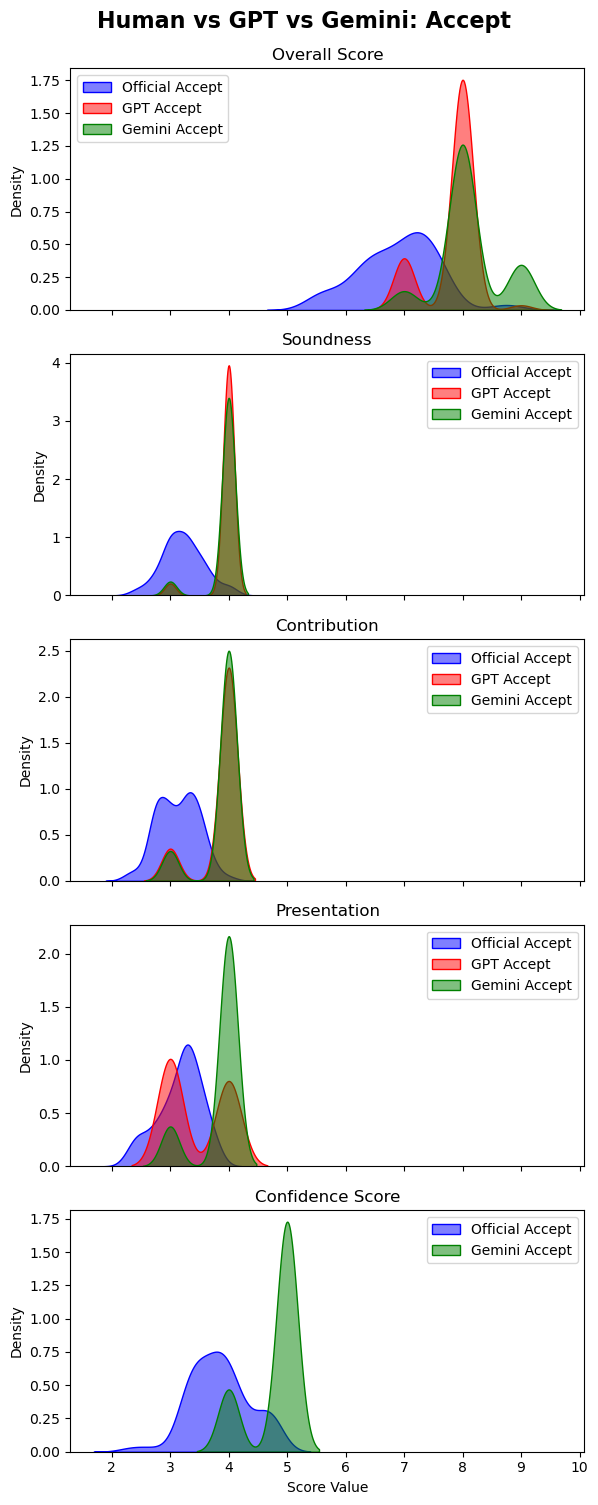

In [52]:

numerical_columns = ['Overall Score','Soundness','Contribution', 'Presentation','Confidence Score']
fig, axs = plt.subplots(len(numerical_columns), 1, figsize=(6, 15), sharex=True)

fig.suptitle("Human vs GPT vs Gemini: Accept", fontsize=16, fontweight='bold', y=1.00)  

# Loop through each numerical column and plot KDE distributions
for i, col in enumerate(numerical_columns):
    sns.kdeplot(df_official[col].dropna(), fill=True, color='blue', alpha=0.5, label="Official Accept", ax=axs[i])
    sns.kdeplot(df_gpt[col].dropna(), fill=True, color='red', alpha=0.5, label="GPT Accept", ax=axs[i])
    sns.kdeplot(df_gem[col].dropna(), fill=True, color='green', alpha=0.5, label="Gemini Accept", ax=axs[i])

    axs[i].set_ylabel('Density')
    axs[i].set_title(f'{col}')
    axs[i].legend()
    
    axs[-1].set_xlabel('Score Value')
    
plt.tight_layout(rect=[0, 0, 1, 1.01]) 
plt.show()

## Human vs GPT vs Gemini (Rejected Papers) Distribution

/var/folders/94/mx6lg9691mncn51yb5t0j2yr0000gn/T/ipykernel_37688/3191789029.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df_gem_r[col].dropna(), fill=True, color='green', alpha=0.5, label="Gemini Reject", ax=axs[i])


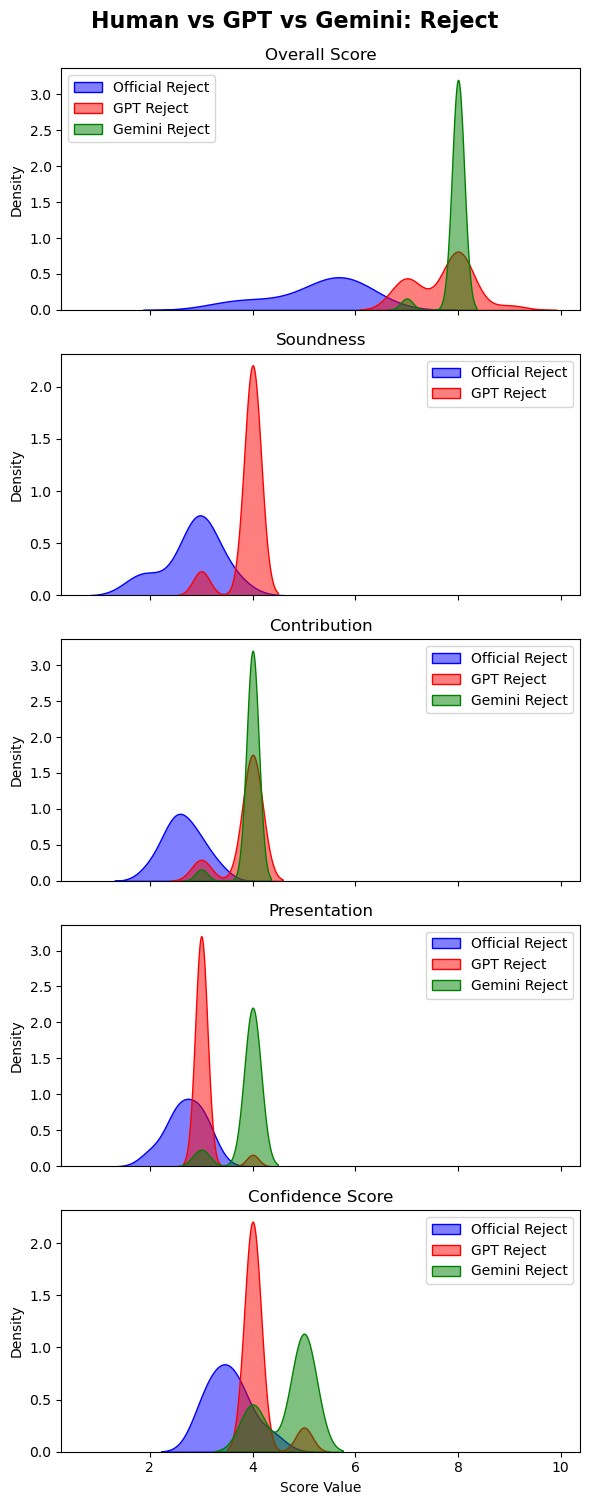

In [54]:

numerical_columns = ['Overall Score','Soundness','Contribution', 'Presentation','Confidence Score']
fig, axs = plt.subplots(len(numerical_columns), 1, figsize=(6, 15), sharex=True)

fig.suptitle("Human vs GPT vs Gemini: Reject", fontsize=16, fontweight='bold', y=1.00)  

# Loop through each numerical column and plot KDE distributions
for i, col in enumerate(numerical_columns):
    sns.kdeplot(df_official_r[col].dropna(), fill=True, color='blue', alpha=0.5, label="Official Reject", ax=axs[i])
    sns.kdeplot(df_gpt_r[col].dropna(), fill=True, color='red', alpha=0.5, label="GPT Reject", ax=axs[i])
    sns.kdeplot(df_gem_r[col].dropna(), fill=True, color='green', alpha=0.5, label="Gemini Reject", ax=axs[i])

    axs[i].set_ylabel('Density')
    axs[i].set_title(f'{col}')
    axs[i].legend()
    
    axs[-1].set_xlabel('Score Value')
    
plt.tight_layout(rect=[0, 0, 1, 1.01]) 
plt.show()

## Mann Whitney U Test -  Human vs LLMs

In [55]:

# Define numerical columns for comparison
numerical_columns = ['Overall Score', 'Soundness', 'Contribution', 'Presentation', 'Confidence Score']
p_values = {}

# Perform Mann-Whitney U Test
for col in numerical_columns:
    stat, p_val = mannwhitneyu(df_official[col].dropna(), df_gpt[col].dropna(), alternative='two-sided')
    p_values[col] = p_val

p_values_df = pd.DataFrame(list(p_values.items()), columns=['Metric', 'P-Value'])
p_values_df['Significance'] = p_values_df['P-Value'].apply(lambda x: "Significant" if x < 0.05 else "Not Significant")

# Print results in a tabular format
print('-------- Human vs GPT: ACCEPT Papers --------')
print(tabulate(p_values_df, headers='keys', tablefmt='grid'))

-------- Human vs GPT: ACCEPT Papers --------
+----+------------------+-------------+----------------+
|    | Metric           |     P-Value | Significance   |
+====+==================+=============+================+
|  0 | Overall Score    | 9.49097e-16 | Significant    |
+----+------------------+-------------+----------------+
|  1 | Soundness        | 1.8842e-20  | Significant    |
+----+------------------+-------------+----------------+
|  2 | Contribution     | 7.56794e-18 | Significant    |
+----+------------------+-------------+----------------+
|  3 | Presentation     | 0.0294917   | Significant    |
+----+------------------+-------------+----------------+
|  4 | Confidence Score | 0.000687984 | Significant    |
+----+------------------+-------------+----------------+


In [56]:
# Define numerical columns for comparison
numerical_columns = ['Overall Score', 'Soundness', 'Contribution', 'Presentation', 'Confidence Score']
p_values = {}

# Perform Mann-Whitney U Test
for col in numerical_columns:
    stat, p_val = mannwhitneyu(df_official_r[col].dropna(), df_gpt_r[col].dropna(), alternative='two-sided')
    p_values[col] = p_val

p_values_df = pd.DataFrame(list(p_values.items()), columns=['Metric', 'P-Value'])
p_values_df['Significance'] = p_values_df['P-Value'].apply(lambda x: "Significant" if x < 0.05 else "Not Significant")

# Print results in a tabular format
print('-------- Human vs GPT: REJECT --------')
print(tabulate(p_values_df, headers='keys', tablefmt='grid'))

-------- Human vs GPT: REJECT --------
+----+------------------+-------------+----------------+
|    | Metric           |     P-Value | Significance   |
+====+==================+=============+================+
|  0 | Overall Score    | 2.02806e-06 | Significant    |
+----+------------------+-------------+----------------+
|  1 | Soundness        | 1.94025e-06 | Significant    |
+----+------------------+-------------+----------------+
|  2 | Contribution     | 1.74325e-06 | Significant    |
+----+------------------+-------------+----------------+
|  3 | Presentation     | 0.00114353  | Significant    |
+----+------------------+-------------+----------------+
|  4 | Confidence Score | 7.86579e-05 | Significant    |
+----+------------------+-------------+----------------+


In [57]:
# Define numerical columns for comparison
numerical_columns = ['Overall Score', 'Soundness', 'Contribution', 'Presentation', 'Confidence Score']
p_values = {}

# Perform Mann-Whitney U Test
for col in numerical_columns:
    stat, p_val = mannwhitneyu(df_official[col].dropna(), df_gem[col].dropna(), alternative='two-sided')
    p_values[col] = p_val

p_values_df = pd.DataFrame(list(p_values.items()), columns=['Metric', 'P-Value'])
p_values_df['Significance'] = p_values_df['P-Value'].apply(lambda x: "Significant" if x < 0.05 else "Not Significant")

# Print results in a tabular format
print('--------Human vs Gemini: ACCEPT --------')
print(tabulate(p_values_df, headers='keys', tablefmt='grid'))

--------Human vs Gemini: ACCEPT --------
+----+------------------+-------------+----------------+
|    | Metric           |     P-Value | Significance   |
+====+==================+=============+================+
|  0 | Overall Score    | 2.41933e-19 | Significant    |
+----+------------------+-------------+----------------+
|  1 | Soundness        | 2.11192e-19 | Significant    |
+----+------------------+-------------+----------------+
|  2 | Contribution     | 1.10324e-18 | Significant    |
+----+------------------+-------------+----------------+
|  3 | Presentation     | 2.83098e-16 | Significant    |
+----+------------------+-------------+----------------+
|  4 | Confidence Score | 1.70373e-18 | Significant    |
+----+------------------+-------------+----------------+


In [58]:
# Define numerical columns for comparison
numerical_columns = ['Overall Score', 'Soundness', 'Contribution', 'Presentation', 'Confidence Score']
p_values = {}

# Perform Mann-Whitney U Test
for col in numerical_columns:
    stat, p_val = mannwhitneyu(df_official_r[col].dropna(), df_gem_r[col].dropna(), alternative='two-sided')
    p_values[col] = p_val

# Create a DataFrame for clean output
p_values_df = pd.DataFrame(list(p_values.items()), columns=['Metric', 'P-Value'])
p_values_df['Significance'] = p_values_df['P-Value'].apply(lambda x: "Significant" if x < 0.05 else "Not Significant")

# Print results in a tabular format
print('--------Human vs Gemini: REJECT --------')
print(tabulate(p_values_df, headers='keys', tablefmt='grid'))

--------Human vs Gemini: REJECT --------
+----+------------------+-------------+----------------+
|    | Metric           |     P-Value | Significance   |
+====+==================+=============+================+
|  0 | Overall Score    | 1.53133e-07 | Significant    |
+----+------------------+-------------+----------------+
|  1 | Soundness        | 6.68284e-08 | Significant    |
+----+------------------+-------------+----------------+
|  2 | Contribution     | 2.46986e-07 | Significant    |
+----+------------------+-------------+----------------+
|  3 | Presentation     | 8.67377e-07 | Significant    |
+----+------------------+-------------+----------------+
|  4 | Confidence Score | 7.94511e-06 | Significant    |
+----+------------------+-------------+----------------+


## Check for significant difference between Overall Score and Primary Area
There is no significant difference between primary area and overall score

In [59]:
# from scipy.stats import kruskal
# The Kruskal-Wallis test is a non-parametric test that does not assume normality. 
#It is used to determine whether there is a 
#statistically significant difference in Overall Scores across multiple independent groups (Primary Areas).
dfs = [df_gpt, df_gpt_r, df_gpt_all, df_gem, df_gem_r, df_gem_all, df_official]
for df in dfs:
    primary_areas = df["primary_area"].unique()
    score_groups = [df[df["primary_area"] == area]["Overall Score"].dropna() for area in primary_areas]
    kruskal_stat, kruskal_p = kruskal(*score_groups)
    print(f"Kruskal-Wallis Test p-value: {kruskal_p:.5f}")
    if kruskal_p < 0.05:
        print("❌ Significant difference detected in scores by Primary Area (reject H0).")
    else:
        print("✅ No significant difference detected (fail to reject H0).")

Kruskal-Wallis Test p-value: 0.07322
✅ No significant difference detected (fail to reject H0).
Kruskal-Wallis Test p-value: 0.34432
✅ No significant difference detected (fail to reject H0).
Kruskal-Wallis Test p-value: 0.06302
✅ No significant difference detected (fail to reject H0).
Kruskal-Wallis Test p-value: 0.25405
✅ No significant difference detected (fail to reject H0).
Kruskal-Wallis Test p-value: 0.48540
✅ No significant difference detected (fail to reject H0).
Kruskal-Wallis Test p-value: 0.28329
✅ No significant difference detected (fail to reject H0).
Kruskal-Wallis Test p-value: nan
✅ No significant difference detected (fail to reject H0).


## Observe mean and median scores between LLMs and Human reviews

In [60]:
dfs = {"Gemini Accept": df_gem, "GPT Accept": df_gpt," Human Accept": df_official}
mean_dict = {}
median_dict = {}

common_columns = ['Overall Score', 'Soundness', 'Contribution', 'Presentation','Confidence Score']
for name, df in dfs.items():
    df_filtered = df[common_columns]  # Select only the columns present in df_official_r
    mean_dict[name] = df_filtered.mean(numeric_only=True)
    median_dict[name] = df_filtered.median(numeric_only=True)

mean_df = pd.DataFrame(mean_dict)
median_df = pd.DataFrame(median_dict)

# Combine mean and median into a single DataFrame
summary_df = pd.concat([mean_df, median_df], keys=["Mean", "Median"])

print(summary_df)

                         Gemini Accept  GPT Accept   Human Accept
Mean   Overall Score          8.114754    7.836066       6.897778
       Soundness              3.934426    3.950820       3.216444
       Contribution           3.885246    3.868852       3.130000
       Presentation           3.852459    3.442623       3.164000
       Confidence Score       4.786885    4.000000       3.844444
Median Overall Score          8.000000    8.000000       7.000000
       Soundness              4.000000    4.000000       3.250000
       Contribution           4.000000    4.000000       3.250000
       Presentation           4.000000    3.000000       3.250000
       Confidence Score       5.000000    4.000000       3.750000


In [61]:
dfs = {"Gemini Reject": df_gem_r, "GPT Reject": df_gpt_r," Human Reject": df_official_r}
mean_dict = {}
median_dict = {}


common_columns = ['Overall Score', 'Soundness', 'Contribution', 'Presentation','Confidence Score']

for name, df in dfs.items():
    df_filtered = df[common_columns]  # Select only the columns present in df_official_r
    mean_dict[name] = df_filtered.mean(numeric_only=True)
    median_dict[name] = df_filtered.median(numeric_only=True)

mean_df = pd.DataFrame(mean_dict)
median_df = pd.DataFrame(median_dict)

# Combine mean and median into a single DataFrame
summary_df = pd.concat([mean_df, median_df], keys=["Mean", "Median"])

print(summary_df)

                         Gemini Reject  GPT Reject   Human Reject
Mean   Overall Score          7.952381    7.714286       5.278788
       Soundness              4.000000    3.904762       2.833333
       Contribution           3.952381    3.857143       2.648485
       Presentation           3.904762    3.047619       2.701515
       Confidence Score       4.714286    4.095238       3.536364
Median Overall Score          8.000000    8.000000       5.400000
       Soundness              4.000000    4.000000       3.000000
       Contribution           4.000000    4.000000       2.666667
       Presentation           4.000000    3.000000       2.666667
       Confidence Score       5.000000    4.000000       3.500000


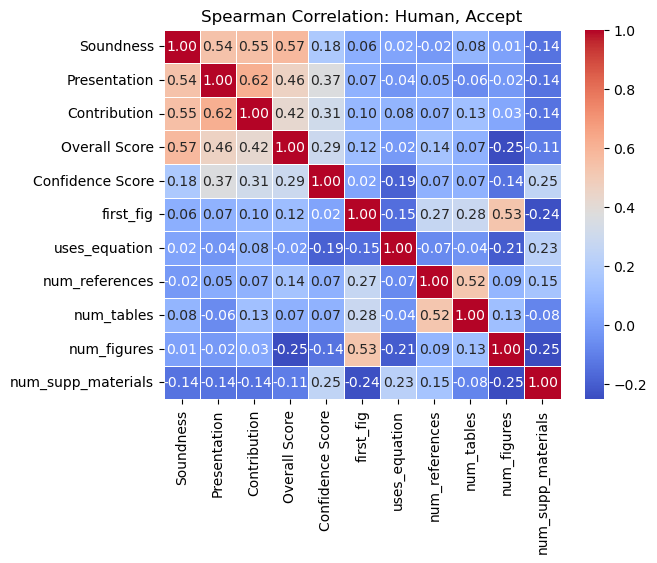

In [62]:
df_official[['primary_area', 'first_fig',
       'uses_equation', 'num_references', 'num_tables', 'num_figures',
       'num_supp_materials']] = df_gpt[['primary_area', 'first_fig',
       'uses_equation', 'num_references', 'num_tables', 'num_figures',
       'num_supp_materials']]

df_official_r[['primary_area', 'first_fig',
       'uses_equation', 'num_references', 'num_tables', 'num_figures',
       'num_supp_materials']] = df_gpt_r[['primary_area', 'first_fig',
       'uses_equation', 'num_references', 'num_tables', 'num_figures',
       'num_supp_materials']]
corr_matrix_official = df_official.corr(method='spearman') 
sns.heatmap(corr_matrix_official, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Spearman Correlation: Human, Accept")
plt.show()

In [63]:
df_official_all =  pd.concat([df_official, df_official_r])

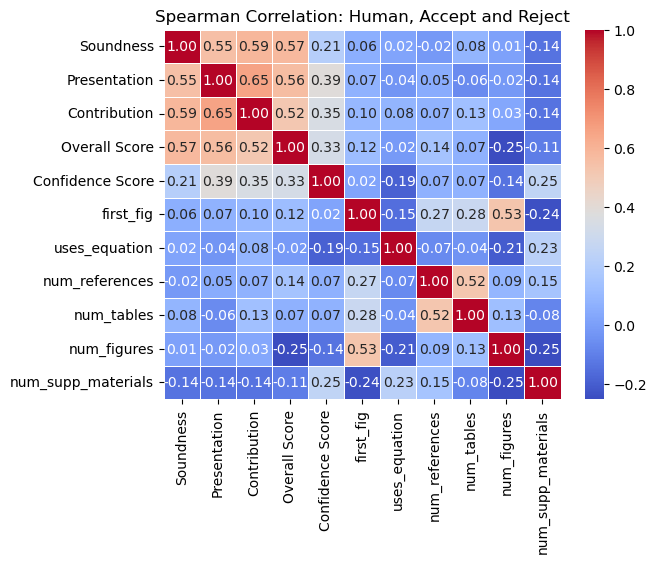

In [64]:
corr_matrix_official_all = df_official_all.corr(method='spearman') 
sns.heatmap(corr_matrix_official_all, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Spearman Correlation: Human, Accept and Reject")
plt.show()